# 1. Normalize data and aggregate dataset

In [ ]:
""""
Подготовка нормализованного датасета для заданного типа датчика с геометрическими параметрами
Этот скрипт:
1. Принимает тип датчика (A, B, C, D, E) как параметр
2. Загружает все датасеты указанного типа датчика
3. Собирает все состояния (как P, так и Q) для кластеризации
4. Находит центры масс кластеров всех состояний
5. Использует центры масс кластеров как эталонное P-состояние
6. Сортирует маркеры в эталонном состоянии в порядке слева-направо и сверху-вниз
7. Для каждого состояния сопоставляет маркеры с эталонным состоянием по принципу ближайшего соседа
8. Вычисляет векторы деформаций как разность между сопоставленными точками (Q-P)
9. Вычисляет сумму L2 норм векторов деформаций для каждого замера
10. Добавляет геометрические параметры датчика (D, M) из SENSOR_GEOMETRY
11. Сохраняет агрегированный датасет со всеми этими данными в формате, совместимом с кодом обучения
12. В конце отображает два графика:
- Эталонное нормированное P-состояние (центры масс кластеров)
- Все нормированные состояния всех датасетов, наложенные друг на друга, с центрами масс кластеров
"""
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from tqdm import tqdm
import json
from scipy.spatial import KDTree
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
# =======================
# ГЕОМЕТРИЧЕСКИЕ ПАРАМЕТРЫ ДАТЧИКОВ И КОЛИЧЕСТВО МАРКЕРОВ
# =======================
SENSOR_GEOMETRY = {
    'A': {'D': 8.69, 'M': 12},  # 12 маркеров (3x4 сетка)
    'B': {'D': 6.94, 'M': 15},  # 15 маркеров (3x5 сетка)
    'C': {'D': 6.47, 'M': 20},  # 20 маркеров (4x5 сетка)
    'D': {'D': 5.75, 'M': 24},  # 24 маркера (4x6 сетка)
    'E': {'D': 5.14, 'M': 30}   # 30 маркеров (5x6 сетка)
}
# =======================
# Конфигурационные параметры
# =======================
# Пути к данным
BASE_DIR = Path("Datasets")
LABELLED_DIR = BASE_DIR / "Labelled"
# Параметр типа датчика (можно изменить здесь или передать в функцию)
SENSOR_TYPE = 'E'  # Может быть 'A', 'B', 'C', 'D', 'E'
# Параметры определения начальных состояний
P_THRESHOLD = 0.1  # Порог силы для начальных состояний (Н)
MIN_P_STATES = 1   # Минимальное количество P-состояний в датасете
# Параметры кластеризации
MIN_CLUSTER_SIZE = 3          # Минимальное количество точек в кластере для его учета
# Параметры визуализации
FIG_WIDTH = 25
FIG_HEIGHT = 8
DPI = 100
TITLE_FONT = 14
AXIS_FONT = 12
TICK_FONT = 10
ANNOT_FONT = 8
P_MARKER_SIZE = 80
Q_MARKER_SIZE = 15
P_ALPHA = 0.9
Q_ALPHA = 0.1
P_COLOR = '#1f77b4'           # синий для нормализованных P состояний
Q_COLOR = '#ff7f0e'           # оранжевый для нормализованных Q состояний
CLUSTER_CENTER_COLOR = '#2ca02c'  # зеленый для центров масс кластеров
ADJUSTED_P_COLOR = '#d62728'  # красный для скорректированных P состояний
GRID_ALPHA = 0.3
MARKER_CORRESPONDENCE_COLOR = '#e377c2'  # розовый для линий соответствия точек
CORRESPONDENCE_ALPHA = 0.5
CORRESPONDENCE_LINEWIDTH = 1.0
plt.rcParams.update({
    'figure.titlesize': TITLE_FONT,
    'axes.titlesize': TITLE_FONT,
    'axes.labelsize': AXIS_FONT,
    'xtick.labelsize': TICK_FONT,
    'ytick.labelsize': TICK_FONT,
    'legend.fontsize': ANNOT_FONT,
    'font.family': 'sans-serif'
})
# =======================
# Вспомогательные функции
# =======================
def _fmt_two(v):
    """Return 2-digit zero-padded string for day/month, preserving already string input."""
    try:
        vi = int(v)
        return f"{vi:02d}"
    except Exception:
        s = str(v)
        return s.zfill(2) if len(s) < 2 else s
def _fmt_membrane(m):
    """
    Normalize membrane flag to a string with at least 3 digits, preserving leading zeros
    if the user provided them as string (e.g. "015") or when provided as int (15 -> "015").
    """
    if isinstance(m, (int, np.integer)):
        return f"{int(m):03d}"
    s = str(m)
    # strip possible whitespace
    s = s.strip()
    # if s represents an integer (e.g. "015" or "15"), zero-pad to 3 digits
    if re.fullmatch(r"\d+", s):
        return s.zfill(3)
    # otherwise, return as-is
    return s
def sort_points_left_to_right_top_to_bottom(points):
    """
    Сортирует точки в порядке слева-направо и сверху-вниз
    Args:
        points: массив точек формы (n_points, 2)
    Returns:
        sorted_points: отсортированные точки
        sorted_indices: исходные индексы точек после сортировки
    """
    # Копируем точки для сортировки
    points_copy = points.copy()
    # Сначала сортируем по Y (сверху вниз, т.е. по возрастанию Y)
    # Затем сортируем по X (слева направо, т.е. по возрастанию X)
    sorted_indices = np.lexsort((points_copy[:, 0], points_copy[:, 1]))
    sorted_points = points_copy[sorted_indices]
    return sorted_points, sorted_indices
def find_nearest_correspondences(reference_points, target_points):
    """
    Находит ближайшие соответствия между точками эталонного состояния и целевого состояния
    Args:
        reference_points: эталонные точки (уже отсортированные в нужном порядке), форма (n_points, 2)
        target_points: целевые точки, форма (n_points, 2)
    Returns:
        correspondences: массив индексов соответствий, где correspondences[i] = j означает,
        что i-тая точка из reference_points соответствует j-той точке из target_points
        distances: расстояния до ближайших соседей
    """
    n_points = len(reference_points)
    # Проверяем наличие NaN и Inf в данных
    finite_mask = np.all(np.isfinite(target_points), axis=1)
    if not np.all(finite_mask):
        print(f"Предупреждение: target_points содержит NaN или Inf значения.")
        num_finite = np.sum(finite_mask)
        print(f"  Количество корректных точек: {num_finite} из {n_points}")
        if num_finite < n_points:
            print(f"  Недостаточно корректных точек для точного сопоставления. Используется запасной метод.")
            # Если недостаточно корректных точек, возвращаем соответствие по порядку
            return np.arange(n_points), np.full(n_points, np.nan)
    # Фильтруем точки
    target_points_finite = target_points[finite_mask]
    original_indices = np.where(finite_mask)[0]
    try:
        # Создаем KDTree для целевых точек для быстрого поиска ближайших соседей
        tree = KDTree(target_points_finite)
        # Находим ближайшего соседа для каждой точки из reference_points
        distances, indices = tree.query(reference_points, k=1)
        # Преобразуем индексы обратно к оригинальным
        original_indices_mapped = original_indices[indices]
        return original_indices_mapped, distances
    except Exception as e:
        print(f"Ошибка при работе с KDTree: {e}")
        print(f"reference_points shape: {reference_points.shape}, all finite: {np.all(np.isfinite(reference_points))}")
        print(f"target_points_finite shape: {target_points_finite.shape}, all finite: {np.all(np.isfinite(target_points_finite))}")
        # Возвращаем соответствие по порядку при ошибке
        return np.arange(n_points), np.full(n_points, np.nan)
def compute_deformation_vectors(reference_points, target_points, correspondences):
    """
    Вычисляет векторы деформаций между эталонными и целевыми точками с учетом соответствий
    Args:
        reference_points: эталонные точки, форма (n_points, 2)
        target_points: целевые точки, форма (n_points, 2)
        correspondences: массив соответствий, где correspondences[i] = j означает,
        что i-тая точка из reference_points соответствует j-той точке из target_points
    Returns:
        deformation_vectors: массив векторов деформаций, форма (n_points, 2)
    """
    n_points = len(reference_points)
    deformation_vectors = np.zeros((n_points, 2))
    for i in range(n_points):
        ref_point = reference_points[i]
        if correspondences[i] < len(target_points):
            target_point = target_points[correspondences[i]]
        else:
            # Если индекс выходит за границы, используем ближайшую доступную точку
            target_point = target_points[-1]
            print(f"Предупреждение: индекс {correspondences[i]} выходит за границы массива размером {len(target_points)}")
        deformation_vectors[i] = target_point - ref_point
    return deformation_vectors
def compute_total_l2_norm(deformation_vectors):
    """
    Вычисляет сумму L2 норм (евклидовых расстояний) для всех векторов деформаций
    Args:
        deformation_vectors: массив векторов деформаций, форма (n_points, 2)
    Returns:
        float: сумма L2 норм всех векторов
    """
    # Вычисляем L2 норму для каждого вектора и суммируем
    l2_norms = np.linalg.norm(deformation_vectors, axis=1)
    total_l2 = np.sum(l2_norms)
    return total_l2
def find_all_datasets_by_type(sensor_type):
    """
    Находит все датасеты указанного типа датчика
    Args:
        sensor_type: тип датчика ('A', 'B', 'C', 'D', 'E')
    Returns:
        list: Список путей к директориям датасетов
    """
    if not LABELLED_DIR.exists():
        print(f"Директория {LABELLED_DIR} не существует")
        return []
    datasets = []
    pattern = f"{sensor_type}_m*"
    # Ищем датасеты в директории Labelled
    for item in LABELLED_DIR.iterdir():
        if item.is_dir() and item.name.startswith(f"{sensor_type}_m"):
            datasets.append(item)
    # Если не нашли, ищем в поддиректориях
    if not datasets:
        for item in LABELLED_DIR.rglob("*"):
            if item.is_dir() and item.name.startswith(f"{sensor_type}_m"):
                datasets.append(item.parent / item.name)
    if not datasets:
        print(f"Не найдено датасетов с датчиком типа {sensor_type} в {LABELLED_DIR}")
        return []
    # Сортируем по имени для последовательного отображения
    datasets.sort(key=lambda x: x.name)
    print(f"Найдено датасетов с датчиком типа {sensor_type}: {len(datasets)}")
    for i, ds in enumerate(datasets, 1):
        print(f"{i}. {ds.name}")
    return datasets
def load_dataset_data(dataset_dir, sensor_type):
    """
    Загружает данные из датасета с определением начальных состояний по силе
    Args:
        dataset_dir (Path): Путь к директории датасета
        sensor_type (str): Тип датчика для определения количества маркеров
    Returns:
        tuple: (markers_by_idx, dataset_info) или (None, None) в случае ошибки
    """
    dataset_name = dataset_dir.name
    # Получаем количество маркеров из значения 'M' в SENSOR_GEOMETRY
    sensor_params = SENSOR_GEOMETRY.get(sensor_type, {})
    num_markers = sensor_params.get('M', 15)  # По умолчанию 15 маркеров
    # Поиск файлов с данными
    inputs_path = None
    outputs_path = None
    # Ищем файлы inputs и outputs
    for file in dataset_dir.iterdir():
        if file.name.lower().startswith('inputs') and file.suffix == '.csv':
            inputs_path = file
        elif file.name.lower().startswith('outputs') and file.suffix == '.csv':
            outputs_path = file
    # Если не нашли, пробуем глубокий поиск
    if inputs_path is None:
        inputs_candidates = list(dataset_dir.glob("**/*inputs*.csv"))
        if inputs_candidates:
            inputs_path = inputs_candidates[0]
    if outputs_path is None:
        outputs_candidates = list(dataset_dir.glob("**/*outputs*.csv"))
        if outputs_candidates:
            outputs_path = outputs_candidates[0]
    if inputs_path is None or outputs_path is None:
        print(f"Не удалось найти файлы с данными в {dataset_dir}")
        return None, None
    # Загружаем данные
    try:
        marker_positions = pd.read_csv(inputs_path)
        force_data = pd.read_csv(outputs_path)
    except Exception as e:
        print(f"Ошибка загрузки данных из {dataset_dir}: {e}")
        return None, None
    # Проверяем наличие нужных столбцов
    required_cols_inputs = ['marker_id', 'x_coord', 'y_coord', 'annotation_idx']
    for col in required_cols_inputs:
        if col not in marker_positions.columns:
            print(f"В файле {inputs_path.name} отсутствует необходимый столбец: {col}")
            return None, None
    # Определяем колонку с силой
    force_col = None
    possible_force_cols = ['force_value_N', 'force_value', 'force_N', 'force', 'force_value_N.1']
    for col in possible_force_cols:
        if col in force_data.columns:
            force_col = col
            break
    if force_col is None:
        # Берем первую числовую колонку, кроме индекса
        numeric_cols = force_data.select_dtypes(include=[np.number]).columns.tolist()
        if numeric_cols:
            force_col = numeric_cols[0]
    if force_col is None:
        print(f"Не удалось определить колонку с силой в {outputs_path}")
        print(f"Доступные столбцы: {force_data.columns.tolist()}")
        return None, None
    # Определяем колонку с индексами замеров в force_data
    idx_col = None
    possible_idx_cols = ['annotation_idx', 'frame_idx', 'idx', 'index']
    for col in possible_idx_cols:
        if col in force_data.columns:
            idx_col = col
            break
    if idx_col is None:
        # Если нет явной колонки индексов, предполагаем соответствие порядку
        if len(force_data) == marker_positions['annotation_idx'].nunique():
            force_data['annotation_idx'] = sorted(marker_positions['annotation_idx'].unique())
            idx_col = 'annotation_idx'
        else:
            print(f"Не удалось сопоставить замеры по индексам в {dataset_dir}")
            print(f"Количество уникальных индексов в inputs: {marker_positions['annotation_idx'].nunique()}")
            print(f"Количество строк в outputs: {len(force_data)}")
            return None, None
    # Создаем словарь сопоставления индексов и сил
    force_dict = {}
    for _, row in force_data.iterrows():
        ann_idx = row[idx_col]
        # Приводим к целому числу если возможно
        try:
            ann_idx = int(ann_idx)
        except (TypeError, ValueError):
            pass
        force_value = row[force_col]
        force_dict[ann_idx] = force_value
    # Сортируем данные по annotation_idx
    marker_positions = marker_positions.sort_values(['annotation_idx', 'marker_id'])
    # Получаем уникальные индексы измерений
    unique_indices = sorted(marker_positions['annotation_idx'].unique())
    M = len(unique_indices)  # Количество замеров
    # Извлекаем позиции маркеров для каждого замера
    markers_by_idx = {}
    original_markers_by_idx = {}  # Сохраняем исходные координаты для визуализации
    for idx in unique_indices:
        frame_data = marker_positions[marker_positions['annotation_idx'] == idx]
        # Сортируем по marker_id
        frame_data = frame_data.sort_values('marker_id')
        coords = frame_data[['x_coord', 'y_coord']].values
        # Проверяем количество маркеров
        if coords.shape[0] != num_markers:
            print(f"Предупреждение: в замере {idx} датасета {dataset_name} "
                  f"обнаружено {coords.shape[0]} маркеров вместо ожидаемых {num_markers}. "
                  f"Пропускаем этот замер.")
            continue
        # Проверяем наличие NaN или Inf в координатах
        if not np.all(np.isfinite(coords)):
            print(f"Предупреждение: в замере {idx} датасета {dataset_name} "
                  f"обнаружены NaN или Inf значения в координатах. Пропускаем этот замер.")
            continue
        # Сохраняем как нормализованные (будут преобразованы позже), так и исходные координаты
        markers_by_idx[idx] = coords.copy()
        original_markers_by_idx[idx] = coords.copy()
    # Определяем начальные состояния (P) по порогу силы
    P_indices = [idx for idx in unique_indices if idx in markers_by_idx and force_dict.get(idx, np.inf) < P_THRESHOLD]
    # Если недостаточно P-состояний, берем замеры с минимальной силой
    if len(P_indices) < MIN_P_STATES:
        # Сортируем индексы по возрастанию силы
        sorted_indices = sorted([idx for idx in unique_indices if idx in markers_by_idx],
                               key=lambda idx: force_dict.get(idx, np.inf))
        P_indices = sorted_indices[:MIN_P_STATES]
        min_forces = [force_dict.get(idx, np.inf) for idx in P_indices]
        print(f"Предупреждение: в датасете {dataset_name} недостаточно замеров с силой < {P_THRESHOLD} Н")
        print(f"Взяты {len(P_indices)} замеров с минимальной силой: {min_forces}")
    # Информация о датасете
    dataset_info = {
        'name': dataset_name,
        'markers_count': num_markers,  # Количество маркеров для данного типа датчика
        'measurements_count': M,
        'directory': str(dataset_dir),
        'annotation_indices': unique_indices,
        'marker_ids': list(range(num_markers)),  # Стандартная нумерация маркеров
        'force_col': force_col,
        'force_dict': force_dict,
        'P_indices': P_indices,
        'original_coordinates': original_markers_by_idx  # Исходные координаты для визуализации
    }
    print(f"\nЗагружен датасет: {dataset_name}")
    print(f"  Количество маркеров: {dataset_info['markers_count']}")
    print(f"  Количество измерений: {dataset_info['measurements_count']}")
    print(f"  Количество P-состояний (начальных): {len(P_indices)}")
    print(f"  Силы P-состояний: {[force_dict.get(idx, np.inf) for idx in P_indices]}")
    return markers_by_idx, dataset_info
def find_cluster_centers(all_states, num_clusters):
    """
    Находит центры масс кластеров для всех состояний
    Args:
        all_states: список всех состояний
        num_clusters: количество кластеров (равно количеству маркеров)
    Returns:
        cluster_centers: массив координат центров кластеров
    """
    print("\nПоиск центров масс кластеров всех состояний...")
    print(f"Общее количество состояний: {len(all_states)}")
    # Объединяем все точки из всех состояний в один массив
    all_points = np.vstack(all_states)
    print(f"Общее количество точек для кластеризации: {len(all_points)}")
    # Применяем KMeans для кластеризации
    print(f"Применение KMeans с количеством кластеров: {num_clusters}")
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(all_points)
    # Получаем координаты центров кластеров
    cluster_centers = kmeans.cluster_centers_
    # Вычисляем инерцию (сумму квадратов расстояний от точек до центров их кластеров)
    inertia = kmeans.inertia_
    print(f"Инерция кластеризации: {inertia:.2f}")
    # Вычисляем среднее расстояние от точек до их центров кластеров
    distances = []
    for i, point in enumerate(all_points):
        cluster_idx = kmeans.labels_[i]
        center = cluster_centers[cluster_idx]
        distance = np.linalg.norm(point - center)
        distances.append(distance)
    avg_distance = np.mean(distances)
    max_distance = np.max(distances)
    print(f"Среднее расстояние от точек до центров кластеров: {avg_distance:.2f}")
    print(f"Максимальное расстояние от точек до центров кластеров: {max_distance:.2f}")
    return cluster_centers
def normalize_and_align_datasets(datasets, sensor_type):
    """
    Нормализует все датасеты с использованием центров масс кластеров как эталонного состояния
    и выравнивает маркеры в порядке слева-направо и сверху-вниз
    Args:
        datasets: список путей к датасетам
        sensor_type: тип датчика для определения количества маркеров
    Returns:
        tuple: (reference_P_sorted, all_deformations, all_forces, dataset_info_list,
               marker_correspondences, all_original_states, all_total_l2_norms,
               cluster_centers)
    """
    print("\n" + "="*60)
    print(f"НАЧАЛО НОРМАЛИЗАЦИИ И ВЫРАВНИВАНИЯ ДАННЫХ ДЛЯ ДАТЧИКА ТИПА {sensor_type}")
    print("="*60)
    # Собираем все состояния для кластеризации
    all_states = []  # Список всех состояний для всех датасетов
    all_original_states = []  # Список исходных состояний для визуализации
    dataset_full_info = []  # Полная информация о датасетах с markers_by_idx
    # Определяем количество маркеров для данного типа датчика
    sensor_params = SENSOR_GEOMETRY.get(sensor_type, {})
    num_markers = sensor_params.get('M', 15)
    print(f"Количество маркеров для датчика типа {sensor_type}: {num_markers}")
    print("Шаг 1: Загрузка данных и сбор всех состояний...")
    valid_datasets = 0
    for dataset_dir in tqdm(datasets, desc="Загрузка датасетов"):
        markers_by_idx, dataset_info = load_dataset_data(dataset_dir, sensor_type)
        if markers_by_idx is None:
            continue
        # Проверяем наличие хотя бы одного состояния
        valid_indices = [idx for idx in dataset_info['annotation_indices'] if idx in markers_by_idx]
        if len(valid_indices) == 0:
            print(f"Пропускаем датасет {dataset_dir.name}: нет валидных состояний")
            continue
        # Собираем все состояния датасета
        dataset_states = []
        dataset_original_states = []
        for idx in valid_indices:
            if idx in markers_by_idx:
                dataset_states.append(markers_by_idx[idx])
                dataset_original_states.append(dataset_info['original_coordinates'][idx])
        # Добавляем состояния в общий список
        all_states.extend(dataset_states)
        all_original_states.extend(dataset_original_states)
        # Сохраняем полную информацию о датасете с markers_by_idx
        full_info = {
            'name': dataset_info['name'],
            'markers_by_idx': markers_by_idx,
            'annotation_indices': dataset_info['annotation_indices'],
            'P_indices': dataset_info['P_indices'],
            'force_dict': dataset_info['force_dict'],
            'marker_ids': dataset_info['marker_ids'],
            'markers_count': dataset_info['markers_count'],
            'original_coordinates': dataset_info['original_coordinates']
        }
        dataset_full_info.append(full_info)
        valid_datasets += 1
    if not all_states:
        print("Ошибка: не удалось загрузить ни одного валидного датасета")
        return None, None, None, None, None, None, None, None
    print(f"\nВсего загружено валидных датасетов: {valid_datasets}")
    print(f"Количество собранных состояний: {len(all_states)}")
    print(f"Количество маркеров в каждом датасете: {num_markers}")
    # Шаг 2: Поиск центров масс кластеров всех состояний
    print("\nШаг 2: Поиск центров масс кластеров всех состояний...")
    cluster_centers = find_cluster_centers(all_states, num_markers)
    # Сортируем центры масс в порядке слева-направо и сверху-вниз
    reference_P_sorted, sorted_indices = sort_points_left_to_right_top_to_bottom(cluster_centers)
    print(f"Центры масс отсортированы. Исходные индексы после сортировки: {sorted_indices}")
    print(f"Эталонное состояние (центры масс) вычислено и отсортировано. Форма: {reference_P_sorted.shape}")
    # Подготавливаем данные для агрегированного датасета
    print("\nШаг 3: Обработка всех состояний и вычисление векторов деформаций...")
    all_deformations = []  # Список для всех векторов деформаций (Q-P)
    all_forces = []         # Список для всех значений сил
    marker_correspondences = []  # Список соответствий маркеров для каждого замера
    all_total_l2_norms = []  # Список сумм L2 норм для каждого замера
    dataset_info_list = []  # Информация о датасетах
    # Обрабатываем каждый датасет
    for dataset_info in tqdm(dataset_full_info, desc="Обработка датасетов"):
        dataset_name = dataset_info['name']
        markers_by_idx = dataset_info['markers_by_idx']
        annotation_indices = dataset_info['annotation_indices']
        force_dict = dataset_info['force_dict']
        # Обрабатываем каждый замер в датасете
        for idx in annotation_indices:
            if idx not in markers_by_idx:
                continue
            # Получаем текущее состояние
            current_state = markers_by_idx[idx]
            force_value = force_dict.get(idx, np.nan)
            # Проверяем наличие NaN или Inf в данных
            if not np.all(np.isfinite(current_state)) or np.isnan(force_value):
                print(f"Предупреждение: в датасете {dataset_name}, замер {idx} содержатся некорректные значения. Пропускаем.")
                continue
            # Находим соответствия между текущим состоянием и эталонным отсортированным состоянием
            correspondences, distances = find_nearest_correspondences(
                reference_P_sorted, current_state
            )
            # Вычисляем векторы деформаций
            deformation_vectors = compute_deformation_vectors(
                reference_P_sorted, current_state, correspondences
            )
            # Вычисляем сумму L2 норм векторов деформаций
            total_l2_norm = compute_total_l2_norm(deformation_vectors)
            # Добавляем в общие списки
            all_deformations.append(deformation_vectors)
            all_forces.append(force_value)
            all_total_l2_norms.append(total_l2_norm)
            marker_correspondences.append({
                'dataset': dataset_name,
                'measurement_idx': idx,
                'correspondences': correspondences.tolist(),
                'distances': distances.tolist()
            })
            # Добавляем информацию о датасете
            dataset_info_list.append({
                'name': dataset_name,
                'num_measurements': len([idx for idx in annotation_indices if idx in markers_by_idx]),
                'marker_ids': list(range(num_markers))
            })
    if not all_deformations:
        print("Ошибка: не удалось вычислить векторы деформаций для ни одного замера")
        return None, None, None, None, None, None, None, None
    print(f"\nВсего обработано замеров: {len(all_deformations)}")
    print(f"Форма векторов деформаций: {np.array(all_deformations).shape}")
    print(f"Диапазон сил: {min(all_forces):.3f} Н - {max(all_forces):.3f} Н")
    print(f"Диапазон сумм L2 норм: {min(all_total_l2_norms):.3f} - {max(all_total_l2_norms):.3f}")
    return (reference_P_sorted, np.array(all_deformations), np.array(all_forces),
            dataset_info_list, marker_correspondences, all_original_states,
            np.array(all_total_l2_norms), cluster_centers)
# Вспомогательная функция для преобразования numpy типов в стандартные Python типы
def to_serializable(obj):
    if isinstance(obj, (np.integer, np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    if isinstance(obj, (np.floating, np.float64, np.float32, np.float16)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    return obj
def save_aggregated_dataset(reference_P, deformations, forces, dataset_info_list,
                           marker_correspondences, total_l2_norms, cluster_centers,
                           sensor_type):
    """
    Сохраняет агрегированный нормализованный датасет с векторами деформаций, суммами L2 норм
    и геометрическими параметрами датчика, включая информацию о центрах масс кластеров
    Args:
        reference_P: отсортированные центры масс кластеров как эталонное состояние
        deformations: массив векторов деформаций
        forces: массив значений сил
        dataset_info_list: информация о датасетах
        marker_correspondences: соответствия маркеров для каждого замера
        total_l2_norms: массив сумм L2 норм векторов деформаций
        cluster_centers: центры масс кластеров
        sensor_type: тип датчика (A, B, C, D, E)
    Returns:
        Path: путь к сохраненному датасету
    """
    print("\n" + "="*60)
    print(f"СОХРАНЕНИЕ АГРЕГИРОВАННОГО ДАТАСЕТА ДЛЯ ДАТЧИКА ТИПА {sensor_type}")
    print("="*60)
    # Определяем количество датасетов и замеров
    num_measurements = len(forces)
    num_markers = reference_P.shape[0]
    print(f"Статистика по данным:")
    print(f"  Общее количество замеров: {num_measurements}")
    print(f"  Количество датасетов: {len(dataset_info_list)}")
    print(f"  Количество маркеров: {num_markers}")
    print(f"  Форма эталонного состояния: {reference_P.shape}")
    print(f"  Диапазон сумм L2 норм: {np.min(total_l2_norms):.3f} - {np.max(total_l2_norms):.3f}")
    # Получаем геометрические параметры для данного типа датчика
    sensor_params = SENSOR_GEOMETRY.get(sensor_type, {})
    sensor_geometry = {
        'D': sensor_params.get('D', 'N/A'),
        'M': sensor_params.get('M', 'N/A')
    }
    print(f"Геометрические параметры датчика типа {sensor_type}:")
    for param, value in sensor_geometry.items():
        print(f"  {param}: {value}")
    # Создаем директорию для сохранения
    aggregated_dir = LABELLED_DIR / f"Aggregated_deformation_vectors_sensor_{sensor_type}"
    aggregated_dir.mkdir(exist_ok=True)
    # Сохраняем эталонное состояние (центры масс кластеров) с правильным именем файла
    reference_file = aggregated_dir / "reference_P_sorted.npy"
    np.save(reference_file, reference_P)
    print(f"Эталонное состояние (центры масс кластеров) сохранено в: {reference_file}")
    # Сохраняем центры масс кластеров (до сортировки)
    cluster_centers_file = aggregated_dir / "cluster_centers_unsorted.npy"
    np.save(cluster_centers_file, cluster_centers)
    print(f"Центры масс кластеров (до сортировки) сохранены в: {cluster_centers_file}")
    # Сохраняем векторы деформаций
    deformations_file = aggregated_dir / "deformation_vectors.npy"
    np.save(deformations_file, deformations)
    print(f"Векторы деформаций сохранены в: {deformations_file}")
    # Сохраняем значения сил
    forces_file = aggregated_dir / "forces.npy"
    np.save(forces_file, forces)
    print(f"Значения сил сохранены в: {forces_file}")
    # Сохраняем суммы L2 норм
    total_l2_file = aggregated_dir / "total_l2_norms.npy"
    np.save(total_l2_file, total_l2_norms)
    print(f"Суммы L2 норм векторов деформаций сохранены в: {total_l2_file}")
    # Сохраняем соответствия маркеров
    correspondences_file = aggregated_dir / "marker_correspondences.json"
    with open(correspondences_file, 'w', encoding='utf-8') as f:
        json.dump(to_serializable(marker_correspondences), f, indent=2, ensure_ascii=False)
    print(f"Соответствия маркеров сохранены в: {correspondences_file}")
    # Создаем метаинформацию о датасете
    total_samples_per_dataset = {}
    for corr in marker_correspondences:
        dataset_name = corr['dataset']
        total_samples_per_dataset[dataset_name] = total_samples_per_dataset.get(dataset_name, 0) + 1
    meta_info = {
        'sensor_type': sensor_type,
        'sensor_geometry': sensor_geometry,  # Геометрические параметры датчика
        'num_datasets': len(dataset_info_list),
        'num_markers': num_markers,
        'total_measurements': num_measurements,
        'measurements_per_dataset': total_samples_per_dataset,
        'datasets': [info['name'] for info in dataset_info_list],
        'marker_ids': list(range(num_markers)),
        'reference_P_file': str(reference_file),
        'cluster_centers_unsorted_file': str(cluster_centers_file),
        'reference_P_shape': list(reference_P.shape),
        'cluster_centers_unsorted_shape': list(cluster_centers.shape),
        'reference_P_mean': np.mean(reference_P, axis=0).tolist(),
        'cluster_centers_unsorted_mean': np.mean(cluster_centers, axis=0).tolist(),
        'reference_P_std': np.std(reference_P, axis=0).tolist(),
        'cluster_centers_unsorted_std': np.std(cluster_centers, axis=0).tolist(),
        'deformations_shape': list(deformations.shape),
        'total_l2_norms_shape': list(total_l2_norms.shape),
        'total_l2_norms_range': [float(np.min(total_l2_norms)), float(np.max(total_l2_norms))],
        'total_l2_norms_mean': float(np.mean(total_l2_norms)),
        'total_l2_norms_std': float(np.std(total_l2_norms)),
        'force_range': [float(np.min(forces)), float(np.max(forces))],
        'force_mean': float(np.mean(forces)),
        'force_std': float(np.std(forces)),
        'created_at': pd.Timestamp.now().isoformat(),
        'description': (f'Датасет с векторами деформаций относительно эталонного состояния, '
                        f'определенного как центры масс кластеров всех состояний для датчика типа {sensor_type}. '
                        f'Геометрические параметры: {sensor_geometry}. '
                        f'Эталонное состояние отсортировано в порядке слева-направо и сверху-вниз.')
    }
    # Сохраняем метаинформацию
    meta_file = aggregated_dir / "metadata.json"
    with open(meta_file, 'w', encoding='utf-8') as f:
        json.dump(to_serializable(meta_info), f, indent=2, ensure_ascii=False)
    print(f"Метаинформация сохранена в: {meta_file}")
    # Создаем файл с описанием формата данных
    format_description = f"""
Формат данных агрегированного датасета для датчика типа {sensor_type}:
1. reference_P_sorted.npy:
- Форма: ({num_markers}, 2)
- Описание: Эталонное состояние (P-состояние), определенное как центры масс кластеров всех состояний
- Точки отсортированы в порядке слева-направо и сверху-вниз
- Структура: [[x0,y0], [x1,y1], ..., [x{num_markers-1},y{num_markers-1}]]
2. cluster_centers_unsorted.npy:
- Форма: ({num_markers}, 2)
- Описание: Центры масс кластеров всех состояний до сортировки
- Структура: [[x0,y0], [x1,y1], ..., [x{num_markers-1},y{num_markers-1}]]
3. deformation_vectors.npy:
- Форма: ({num_measurements}, {num_markers}, 2)
- Описание: Векторы деформаций для каждого замера относительно эталонного состояния
- Структура: [[[dx0,dy0], [dx1,dy1], ..., [dx{num_markers-1},dy{num_markers-1}]], ...]
- Вектор деформации вычисляется как: Q - P, где Q - положение маркера в деформированном состоянии
4. total_l2_norms.npy:
- Форма: ({num_measurements},)
- Описание: Суммы L2 норм (евклидовых расстояний) всех векторов деформаций для каждого замера
- Это скалярное значение, характеризующее общую степень деформации мембраны
5. forces.npy:
- Форма: ({num_measurements},)
- Описание: Значения силы для каждого замера
- Единицы измерения: Ньютоны (Н)
6. marker_correspondences.json:
- Описание: Соответствия между маркерами в эталонном и деформированном состояниях
- Структура: Список объектов с информацией о датасете, индексе замера, соответствиях и расстояниях
7. metadata.json:
- Описание: Метаинформация о датасете, включая геометрические параметры датчика:
- sensor_geometry: {{'D': {sensor_geometry.get('D', 'N/A')}, 'M': {sensor_geometry.get('M', 'N/A')}}}
- D: диаметр активной области (мм)
- M: модуль упругости материала (МПа)
Индексация маркеров следует порядку для датчика типа {sensor_type}:
"""
    # Добавляем описание разметки маркеров для каждого типа датчика
    sensor_params = SENSOR_GEOMETRY.get(sensor_type, {})
    num_markers = sensor_params.get('M', 15)
    if sensor_type == 'A':
        format_description += """
- Сетка 3x4: слева-направо и сверху-вниз
- Порядок: [0,1,2,3] - верхняя строка, [4,5,6,7] - средняя строка, [8,9,10,11] - нижняя строка
"""
    elif sensor_type == 'B':
        format_description += """
- Сетка 3x5: слева-направо и сверху-вниз
- Порядок: [0,1,2,3,4] - верхняя строка, [5,6,7,8,9] - средняя строка, [10,11,12,13,14] - нижняя строка
"""
    elif sensor_type == 'C':
        format_description += """
- Сетка 4x5: слева-направо и сверху-вниз
- Порядок: [0,1,2,3,4] - первая строка, [5,6,7,8,9] - вторая строка,
[10,11,12,13,14] - третья строка, [15,16,17,18,19] - четвертая строка
"""
    elif sensor_type == 'D':
        format_description += """
- Сетка 4x6: слева-направо и сверху-вниз
- Порядок: [0,1,2,3,4,5] - первая строка, [6,7,8,9,10,11] - вторая строка,
[12,13,14,15,16,17] - третья строка, [18,19,20,21,22,23] - четвертая строка
"""
    elif sensor_type == 'E':
        format_description += """
- Сетка 5x6: слева-направо и сверху-вниз
- Порядок: [0,1,2,3,4,5] - первая строка, [6,7,8,9,10,11] - вторая строка,
[12,13,14,15,16,17] - третья строка, [18,19,20,21,22,23] - четвертая строка,
[24,25,26,27,28,29] - пятая строка
"""
    else:
        format_description += "- Стандартный порядок сортировки слева-направо и сверху-вниз\n"
    format_file = aggregated_dir / "format_description.txt"
    with open(format_file, 'w', encoding='utf-8') as f:
        f.write(format_description)
    print(f"Описание формата данных сохранено в: {format_file}")
    print(f"\nАгрегированный датасет сохранен в: {aggregated_dir}")
    print(f"  Эталонное состояние: {reference_file}")
    print(f"  Центры масс кластеров (до сортировки): {cluster_centers_file}")
    print(f"  Векторы деформаций: {deformations_file}")
    print(f"  Суммы L2 норм: {total_l2_file}")
    print(f"  Силы: {forces_file}")
    print(f"  Соответствия маркеров: {correspondences_file}")
    print(f"  Метаинформация: {meta_file}")
    print(f"  Описание формата: {format_file}")
    print(f"  Геометрические параметры: D={sensor_geometry.get('D', 'N/A')} мм, M={sensor_geometry.get('M', 'N/A')} МПа")
    return aggregated_dir
def visualize_marker_correspondences(reference_P, cluster_centers, states, correspondences, forces, num_samples=5, sensor_type='B'):
    """
    Визуализирует сопоставление маркеров между эталонным и деформированными состояниями
    с добавлением центров масс кластеров
    """
    print("\n" + "="*60)
    print(f"ВИЗУАЛИЗАЦИЯ СООТВЕТСТВИЙ МАРКЕРОВ ДЛЯ ДАТЧИКА ТИПА {sensor_type}")
    print("="*60)
    # Выбираем образцы с разными уровнями силы
    force_indices = np.argsort(forces)
    selected_indices = np.linspace(0, len(forces)-1, num_samples, dtype=int)
    selected_indices = force_indices[selected_indices]
    fig, axes = plt.subplots(1, num_samples+1, figsize=(5*(num_samples+1), 6), dpi=DPI)
    # Первый график - общее представление
    ax_overview = axes[0]
    # Строим центры масс кластеров (до сортировки)
    ax_overview.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
                       s=P_MARKER_SIZE*1.5, c=CLUSTER_CENTER_COLOR, alpha=0.9,
                       marker='*', edgecolors='k', linewidths=1.5,
                       label='Центры масс кластеров')
    # Строим эталонное состояние (отсортированные центры масс)
    ax_overview.scatter(reference_P[:, 0], reference_P[:, 1],
                       s=P_MARKER_SIZE, c=P_COLOR, alpha=0.7,
                       marker='o', edgecolors='k', linewidths=1,
                       label='Эталонное P-состояние')
    # Рисуем линии соответствий между неотсортированными и отсортированными центрами масс
    # Создаем KDTree для поиска соответствий
    tree = KDTree(cluster_centers)
    _, indices = tree.query(reference_P)
    for i, center_idx in enumerate(indices):
        ax_overview.plot([reference_P[i, 0], cluster_centers[center_idx, 0]],
                        [reference_P[i, 1], cluster_centers[center_idx, 1]],
                        c=MARKER_CORRESPONDENCE_COLOR, alpha=CORRESPONDENCE_ALPHA*0.5,
                        linewidth=CORRESPONDENCE_LINEWIDTH, linestyle='--')
    ax_overview.set_title(f'Общий обзор эталонного состояния\nдля датчика {sensor_type}', fontsize=TITLE_FONT)
    ax_overview.set_xlabel('X', fontsize=AXIS_FONT)
    ax_overview.set_ylabel('Y', fontsize=AXIS_FONT)
    ax_overview.grid(True, alpha=GRID_ALPHA)
    ax_overview.legend(loc='best', fontsize=ANNOT_FONT)
    ax_overview.set_aspect('equal', adjustable='box')
    # Остальные графики - конкретные примеры
    for i, idx in enumerate(selected_indices, 1):
        ax = axes[i]
        state = states[idx]
        corr = correspondences[idx]['correspondences']
        force = forces[idx]
        # Строим эталонное состояние
        ax.scatter(reference_P[:, 0], reference_P[:, 1],
                  s=P_MARKER_SIZE, c=P_COLOR, alpha=0.8,
                  marker='o', edgecolors='k', linewidths=1,
                  label='Эталонное P')
        # Строим центры масс кластеров
        ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
                  s=P_MARKER_SIZE*0.8, c=CLUSTER_CENTER_COLOR, alpha=0.7,
                  marker='*', edgecolors='k', linewidths=1,
                  label='Центры масс')
        # Строим деформированное состояние
        ax.scatter(state[:, 0], state[:, 1],
                  s=Q_MARKER_SIZE, c=Q_COLOR, alpha=0.8,
                  marker='s', edgecolors='k', linewidths=1,
                  label=f'Q-состояние\nСила: {force:.3f} Н')
        # Рисуем линии соответствий
        for ref_idx, target_idx in enumerate(corr):
            ref_point = reference_P[ref_idx]
            target_point = state[target_idx]
            ax.plot([ref_point[0], target_point[0]],
                   [ref_point[1], target_point[1]],
                   c=MARKER_CORRESPONDENCE_COLOR, alpha=CORRESPONDENCE_ALPHA,
                   linewidth=CORRESPONDENCE_LINEWIDTH, linestyle='--')
        # Добавляем номера маркеров для эталонного состояния
        for j, point in enumerate(reference_P):
            ax.text(point[0] + 0.2, point[1] + 0.2, str(j),
                   fontsize=ANNOT_FONT, fontweight='bold', color=P_COLOR)
        # Добавляем номера маркеров для деформированного состояния
        for j, point in enumerate(state):
            ax.text(point[0] + 0.2, point[1] + 0.2, str(j),
                   fontsize=ANNOT_FONT, fontweight='bold', color=Q_COLOR)
        ax.set_title(f'Сопоставление маркеров\nЗамер #{idx+1}', fontsize=TITLE_FONT)
        ax.set_xlabel('X', fontsize=AXIS_FONT)
        ax.set_ylabel('Y', fontsize=AXIS_FONT)
        ax.grid(True, alpha=GRID_ALPHA)
        ax.set_aspect('equal', adjustable='box')
        if i == 1:
            ax.legend(loc='best', fontsize=ANNOT_FONT)
    fig.suptitle(f'Сопоставление маркеров для датчика типа {sensor_type}',
                fontsize=TITLE_FONT+2, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    # Сохраняем график
    output_dir = Path("results")
    output_dir.mkdir(exist_ok=True)
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    output_path = output_dir / f"marker_correspondences_{sensor_type}_{timestamp}.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"График сопоставления маркеров сохранен: {output_path}")
    plt.close()
    print("\nВизуализация завершена.")
def visualize_deformation_vectors(reference_P, deformations, forces, total_l2_norms, num_samples=5, sensor_type='B'):
    """
    Визуализирует векторы деформаций для выбранных образцов
    Args:
        reference_P: отсортированное эталонное состояние
        deformations: массив векторов деформаций
        forces: значения сил
        total_l2_norms: суммы L2 норм векторов деформаций
        num_samples: количество образцов для визуализации
        sensor_type: тип датчика для заголовка
    """
    print("\n" + "="*60)
    print(f"ВИЗУАЛИЗАЦИЯ ВЕКТОРОВ ДЕФОРМАЦИЙ ДЛЯ ДАТЧИКА ТИПА {sensor_type}")
    print("="*60)
    # Выбираем образцы с разными уровнями силы
    force_indices = np.argsort(forces)
    selected_indices = np.linspace(0, len(forces)-1, num_samples, dtype=int)
    selected_indices = force_indices[selected_indices]
    fig, axes = plt.subplots(1, num_samples, figsize=(5*num_samples, 6), dpi=DPI)
    if num_samples == 1:
        axes = [axes]
    for i, idx in enumerate(selected_indices):
        ax = axes[i]
        deformation = deformations[idx]
        force = forces[idx]
        total_l2 = total_l2_norms[idx]
        # Строим эталонное состояние
        ax.scatter(reference_P[:, 0], reference_P[:, 1],
                  s=P_MARKER_SIZE, c=P_COLOR, alpha=0.8,
                  marker='o', edgecolors='k', linewidths=1,
                  label='Эталонное P')
        # Рисуем векторы деформаций
        for j, (point, vector) in enumerate(zip(reference_P, deformation)):
            # Рисуем вектор
            ax.arrow(point[0], point[1], vector[0], vector[1],
                    head_width=0.1, head_length=0.15, fc='red', ec='red',
                    alpha=0.7, linewidth=1.5)
            # Добавляем номер маркера
            ax.text(point[0] + 0.2, point[1] + 0.2, str(j),
                   fontsize=ANNOT_FONT, fontweight='bold', color=P_COLOR)
        ax.set_title(f'Векторы деформаций\nСила: {force:.3f} Н\nСумма L2: {total_l2:.3f}', fontsize=TITLE_FONT)
        ax.set_xlabel('X', fontsize=AXIS_FONT)
        ax.set_ylabel('Y', fontsize=AXIS_FONT)
        ax.grid(True, alpha=GRID_ALPHA)
        ax.set_aspect('equal', adjustable='box')
        if i == 0:
            ax.legend(loc='best', fontsize=ANNOT_FONT)
    fig.suptitle(f'Векторы деформаций для датчика типа {sensor_type}',
                fontsize=TITLE_FONT+2, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    # Сохраняем график
    output_dir = Path("results")
    output_dir.mkdir(exist_ok=True)
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    output_path = output_dir / f"deformation_vectors_{sensor_type}_{timestamp}.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"График векторов деформаций сохранен: {output_path}")
    plt.close()
    print("\nВизуализация завершена.")
def visualize_final_plots(reference_P, cluster_centers, all_states, sensor_type='B'):
    """
    Отображает два финальных графика в терминале:
    1. Эталонное состояние (центры масс кластеров) и неотсортированные центры масс
    2. Все нормированные состояния всех датасетов, наложенные друг на друга, с эталонным состоянием
    """
    print("\n" + "="*80)
    print(f"ФИНАЛЬНАЯ ВИЗУАЛИЗАЦИЯ ДЛЯ ДАТЧИКА ТИПА {sensor_type}")
    print("="*80)
    print(f"График 1: Эталонное состояние (отсортированные центры масс) и неотсортированные центры масс")
    print(f"График 2: Все нормированные состояния, наложенные друг на друга, с эталонным состоянием")
    print("Закройте окна графиков для завершения программы")
    print("="*80)
    # Создаем фигуру для сравнения отсортированных и неотсортированных центров масс
    plt.figure(figsize=(6, 10), dpi=100)
    # Строим неотсортированные центры масс кластеров
    plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
               s=P_MARKER_SIZE*2, c=CLUSTER_CENTER_COLOR, alpha=0.95,
               marker='*', edgecolors='black', linewidths=2,
               label=f'Центры масс кластеров\n({len(cluster_centers)} точек)')
    # Строим отсортированное эталонное состояние
    plt.scatter(reference_P[:, 0], reference_P[:, 1],
               s=P_MARKER_SIZE*1.5, c=P_COLOR, alpha=0.85,
               marker='o', edgecolors='black', linewidths=1.5,
               label=f'Эталонное P-состояние\n({len(reference_P)} маркеров)')
    # Рисуем линии соответствий между неотсортированными и отсортированными центрами масс
    tree = KDTree(cluster_centers)
    _, indices = tree.query(reference_P)
    for i, center_idx in enumerate(indices):
        plt.plot([reference_P[i, 0], cluster_centers[center_idx, 0]],
                [reference_P[i, 1], cluster_centers[center_idx, 1]],
                c=MARKER_CORRESPONDENCE_COLOR, alpha=CORRESPONDENCE_ALPHA*0.5,
                linewidth=CORRESPONDENCE_LINEWIDTH, linestyle='--')
    # Добавляем номера для всех точек
    for i, (x, y) in enumerate(reference_P):
        plt.text(x + 0.15, y + 0.15, str(i),
                fontsize=9, fontweight='bold', color=P_COLOR)
    for i, (x, y) in enumerate(cluster_centers):
        plt.text(x + 0.15, y - 0.15, str(i),
                fontsize=9, fontweight='bold', color=CLUSTER_CENTER_COLOR)
    # Добавляем сетку и оси
    plt.grid(True, alpha=0.7, linestyle='--')
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    # Статистика по расстояниям
    distances = np.linalg.norm(reference_P - cluster_centers[indices], axis=1)
    avg_distance = np.mean(distances)
    max_distance = np.max(distances)
    title = f'Сравнение отсортированных и неотсортированных центров масс\nдля датчика типа {sensor_type}\n'
    title += f'Среднее расстояние между соответствующими точками: {avg_distance:.2f}\n'
    title += f'Макс. расстояние между соответствующими точками: {max_distance:.2f}'
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('X координата', fontsize=12)
    plt.ylabel('Y координата', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.axis('equal')
    plt.tight_layout()
    # Создаем вторую фигуру для всех состояний
    plt.figure(figsize=(12, 10), dpi=100)
    # Строим все состояния с очень низкой прозрачностью
    print(f"Отображение {len(all_states)} состояний...")
    for i, state in enumerate(all_states):
        if len(state) != len(reference_P):
            print(f"Предупреждение: состояние {i} имеет {len(state)} маркеров вместо {len(reference_P)}")
            continue
        plt.scatter(state[:, 0], state[:, 1],
                   s=Q_MARKER_SIZE*2, c=Q_COLOR, alpha=Q_ALPHA,
                   marker='s', edgecolors='none')
    # Строим эталонное состояние
    plt.scatter(reference_P[:, 0], reference_P[:, 1],
               s=P_MARKER_SIZE*1.5, c=P_COLOR, alpha=0.95,
               marker='o', edgecolors='black', linewidths=2,
               label=f'Эталонное P-состояние\n({len(reference_P)} маркеров)')
    # Добавляем сетку и оси
    plt.grid(True, alpha=0.5, linestyle='--')
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    # Статистика по всем точкам
    all_points = np.vstack(all_states)
    x_min, x_max = np.min(all_points[:, 0]), np.max(all_points[:, 0])
    y_min, y_max = np.min(all_points[:, 1]), np.max(all_points[:, 1])
    x_range = x_max - x_min
    y_range = y_max - y_min
    title = f'Все нормированные состояния для датчика типа {sensor_type}\n'
    title += f'Всего состояний: {len(all_states)}, Общее количество точек: {len(all_points)}\n'
    title += f'Диапазон по X: {x_min:.2f} - {x_max:.2f} ({x_range:.2f})\n'
    title += f'Диапазон по Y: {y_min:.2f} - {y_max:.2f} ({y_range:.2f})'
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('X координата', fontsize=12)
    plt.ylabel('Y координата', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.axis('equal')
    plt.tight_layout()
    # Отображаем оба графика и ждем их закрытия
    print("\nОтображение графиков. Закройте окна для завершения программы...")
    plt.show()
def main():
    """Основная функция для запуска нормализации и подготовки датасета"""
    print("="*80)
    print(f"ПОДГОТОВКА НОРМАЛИЗОВАННОГО ДАТАСЕТА ДЛЯ ДАТЧИКА ТИПА {SENSOR_TYPE}")
    print("="*80)
    print(f"Геометрические параметры для датчика типа {SENSOR_TYPE}:")
    sensor_params = SENSOR_GEOMETRY.get(SENSOR_TYPE, {})
    for param, value in sensor_params.items():
        print(f"  {param}: {value}")
    print(f"Метод определения эталонного состояния: центры масс кластеров всех состояний")
    # Находим все датасеты указанного типа датчика
    datasets = find_all_datasets_by_type(SENSOR_TYPE)
    if not datasets:
        print(f"Нет датасетов для обработки датчика типа {SENSOR_TYPE}. Проверьте директорию Labelled.")
        return
    # Нормализуем и выравниваем все датасеты с использованием центров масс кластеров как эталонного состояния
    result = normalize_and_align_datasets(datasets, SENSOR_TYPE)
    if result[0] is None:
        print("Ошибка при нормализации данных. Завершение работы.")
        return
    (reference_P, deformations, forces, dataset_info_list,
     marker_correspondences, all_original_states, total_l2_norms,
     cluster_centers) = result
    # Визуализируем сопоставление маркеров для нескольких образцов
    print("\nГенерация визуализаций...")
    visualize_marker_correspondences(
        reference_P,
        cluster_centers,
        all_original_states,
        marker_correspondences,
        forces,
        num_samples=5,
        sensor_type=SENSOR_TYPE
    )
    # Визуализируем векторы деформаций
    visualize_deformation_vectors(
        reference_P,
        deformations,
        forces,
        total_l2_norms,
        num_samples=5,
        sensor_type=SENSOR_TYPE
    )
    # Сохраняем агрегированный датасет
    save_aggregated_dataset(
        reference_P,
        deformations,
        forces,
        dataset_info_list,
        marker_correspondences,
        total_l2_norms,
        cluster_centers,
        sensor_type=SENSOR_TYPE
    )
    print("\n" + "="*80)
    print(f"ПОДГОТОВКА ДАТАСЕТА ЗАВЕРШЕНА ДЛЯ ДАТЧИКА ТИПА {SENSOR_TYPE}")
    print("="*80)
    # Выводим финальную статистику
    sensor_params = SENSOR_GEOMETRY.get(SENSOR_TYPE, {})
    num_markers = sensor_params.get('M', 15)
    print(f"\nФинальная статистика:")
    print(f"  Количество датасетов: {len(dataset_info_list)}")
    print(f"  Общее количество замеров: {len(forces)}")
    print(f"  Количество маркеров: {num_markers}")
    print(f"  Диапазон сил: {np.min(forces):.3f} Н - {np.max(forces):.3f} Н")
    print(f"  Средняя сила: {np.mean(forces):.3f} Н")
    print(f"  Стандартное отклонение силы: {np.std(forces):.3f} Н")
    print(f"  Диапазон сумм L2 норм: {np.min(total_l2_norms):.3f} - {np.max(total_l2_norms):.3f}")
    print(f"  Средняя сумма L2 норм: {np.mean(total_l2_norms):.3f}")
    print(f"  Стандартное отклонение L2 норм: {np.std(total_l2_norms):.3f}")
    # Проверяем распределение соответствий маркеров
    correspondences_stats = {}
    for corr in marker_correspondences:
        for ref_idx, target_idx in enumerate(corr['correspondences']):
            key = f"ref_{ref_idx}_to_target_{target_idx}"
            correspondences_stats[key] = correspondences_stats.get(key, 0) + 1
    print(f"\nСтатистика соответствий маркеров (топ-10 самых частых):")
    sorted_stats = sorted(correspondences_stats.items(), key=lambda x: x[1], reverse=True)[:10]
    for key, count in sorted_stats:
        print(f"  {key}: {count} раз")
    # ФИНАЛЬНАЯ ВИЗУАЛИЗАЦИЯ: два графика в терминале
    print("\n" + "="*80)
    print("ФИНАЛЬНАЯ ВИЗУАЛИЗАЦИЯ: ОТКРЫТИЕ ГРАФИКОВ В ОКНАХ")
    print("="*80)
    visualize_final_plots(
        reference_P,
        cluster_centers,
        all_original_states,
        sensor_type=SENSOR_TYPE
    )
    print("\n" + "="*80)
    print("ПРОГРАММА ЗАВЕРШЕНА")
    print("="*80)
if __name__ == "__main__":
    main()

# 2. CV read

In [ ]:
"""
Подготовка нормализованного датасета для датчика типа B с правильным сопоставлением маркеров
Этот скрипт:
1. Загружает все датасеты с датчиком типа B
2. Определяет начальные состояния (P) на основе порога силы
3. Вычисляет эталонное состояние как медиану всех P-состояний
4. Сортирует маркеры в эталонном состоянии в порядке слева-направо и сверху-вниз
5. Для каждого Q-состояния сопоставляет маркеры с эталонным состоянием по принципу ближайшего соседа
6. Вычисляет векторы деформаций как разность между сопоставленными точками (Q-P)
7. ДОПОЛНИТЕЛЬНО: Вычисляет сумму L2 норм векторов деформаций для каждого замера
8. Сохраняет агрегированный датасет в формате:
   - Входные данные: векторы деформаций (deltax, deltay) для всех маркеров
   - ДОПОЛНИТЕЛЬНЫЙ ВХОД: сумма L2 норм векторов деформаций
   - Выходные данные: значения силы для каждого замера
"""
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from tqdm import tqdm
import json
from scipy.spatial import KDTree
import warnings
warnings.filterwarnings('ignore')

# =======================
# Конфигурационные параметры
# =======================
# Пути к данным
BASE_DIR = Path("Datasets")
LABELLED_DIR = BASE_DIR / "Labelled"
# Параметры определения начальных состояний
P_THRESHOLD = 0.1  # Порог силы для начальных состояний (Н)
MIN_P_STATES = 3   # Минимальное количество P-состояний в датасете
NUM_MARKERS_B = 15 # Количество маркеров для датчика типа B
# Параметры визуализации
FIG_WIDTH = 25
FIG_HEIGHT = 8
DPI = 100
TITLE_FONT = 14
AXIS_FONT = 12
TICK_FONT = 10
ANNOT_FONT = 8
P_MARKER_SIZE = 40
Q_MARKER_SIZE = 25
P_ALPHA = 0.3
Q_ALPHA = 0.15
P_COLOR = '#1f77b4'  # синий для нормализованных P состояний
Q_COLOR = '#ff7f0e'  # оранжевый для нормализованных Q состояний
REFERENCE_COLOR = '#2ca02c'  # зеленый для эталонного состояния
GRID_ALPHA = 0.3
MEAN_P_COLOR = '#d62728'  # красный для средних P состояний
SCALED_COLOR = '#9467bd'  # фиолетовый для масштабированных состояний
ORIGINAL_COLOR = '#7f7f7f'  # серый для исходных позиций
BOUNDING_BOX_COLOR = '#8c564b'  # коричневый для баундинг бокса
BOUNDING_BOX_LINEWIDTH = 2
MARKER_CORRESPONDENCE_COLOR = '#e377c2'  # розовый для линий соответствия точек
CORRESPONDENCE_ALPHA = 0.5
CORRESPONDENCE_LINEWIDTH = 1.0

plt.rcParams.update({
    'figure.titlesize': TITLE_FONT,
    'axes.titlesize': TITLE_FONT,
    'axes.labelsize': AXIS_FONT,
    'xtick.labelsize': TICK_FONT,
    'ytick.labelsize': TICK_FONT,
    'legend.fontsize': ANNOT_FONT,
    'font.family': 'sans-serif'
})

# =======================
# Вспомогательные функции
# =======================
def _fmt_two(v):
    """Return 2-digit zero-padded string for day/month, preserving already string input."""
    try:
        vi = int(v)
        return f"{vi:02d}"
    except Exception:
        s = str(v)
        return s.zfill(2) if len(s) < 2 else s

def _fmt_membrane(m):
    """
    Normalize membrane flag to a string with at least 3 digits, preserving leading zeros
    if the user provided them as string (e.g. "015") or when provided as int (15 -> "015").
    """
    if isinstance(m, (int, np.integer)):
        return f"{int(m):03d}"
    s = str(m)
    # strip possible whitespace
    s = s.strip()
    # if s represents an integer (e.g. "015" or "15"), zero-pad to 3 digits
    if re.fullmatch(r"\d+", s):
        return s.zfill(3)
    # otherwise, return as-is
    return s

def sort_points_left_to_right_top_to_bottom(points):
    """
    Сортирует точки в порядке слева-направо и сверху-вниз
    Args:
        points: массив точек формы (n_points, 2)
    Returns:
        sorted_points: отсортированные точки
        sorted_indices: исходные индексы точек после сортировки
    """
    # Копируем точки для сортировки
    points_copy = points.copy()
    
    # Сначала сортируем по Y (сверху вниз, т.е. по возрастанию Y)
    # Затем сортируем по X (слева направо, т.е. по возрастанию X)
    sorted_indices = np.lexsort((points_copy[:, 0], points_copy[:, 1]))
    
    sorted_points = points_copy[sorted_indices]
    return sorted_points, sorted_indices

def find_nearest_correspondences(reference_points, target_points):
    """
    Находит ближайшие соответствия между точками эталонного состояния и целевого состояния
    Args:
        reference_points: эталонные точки (уже отсортированные в нужном порядке), форма (n_points, 2)
        target_points: целевые точки, форма (n_points, 2)
    Returns:
        correspondences: массив индексов соответствий, где correspondences[i] = j означает,
                         что i-тая точка из reference_points соответствует j-той точке из target_points
        distances: расстояния до ближайших соседей
    """
    n_points = len(reference_points)
    
    # Проверяем наличие NaN и Inf в данных
    finite_mask = np.all(np.isfinite(target_points), axis=1)
    if not np.all(finite_mask):
        print(f"Предупреждение: target_points содержит NaN или Inf значения.")
        num_finite = np.sum(finite_mask)
        print(f"  Количество корректных точек: {num_finite} из {n_points}")
        
        if num_finite < n_points:
            print(f"  Недостаточно корректных точек для точного сопоставления. Используется запасной метод.")
            # Если недостаточно корректных точек, возвращаем соответствие по порядку
            return np.arange(n_points), np.full(n_points, np.nan)
        
        # Фильтруем точки
        target_points_finite = target_points[finite_mask]
        original_indices = np.where(finite_mask)[0]
    else:
        target_points_finite = target_points
        original_indices = np.arange(n_points)
    
    try:
        # Создаем KDTree для целевых точек для быстрого поиска ближайших соседей
        tree = KDTree(target_points_finite)
        
        # Находим ближайшего соседа для каждой точки из reference_points
        distances, indices = tree.query(reference_points, k=1)
        
        # Преобразуем индексы обратно к оригинальным
        original_indices_mapped = original_indices[indices]
        
        return original_indices_mapped, distances
    except Exception as e:
        print(f"Ошибка при работе с KDTree: {e}")
        print(f"reference_points shape: {reference_points.shape}, all finite: {np.all(np.isfinite(reference_points))}")
        print(f"target_points_finite shape: {target_points_finite.shape}, all finite: {np.all(np.isfinite(target_points_finite))}")
        # Возвращаем соответствие по порядку при ошибке
        return np.arange(n_points), np.full(n_points, np.nan)

def compute_deformation_vectors(reference_points, target_points, correspondences):
    """
    Вычисляет векторы деформаций между эталонными и целевыми точками с учетом соответствий
    Args:
        reference_points: эталонные точки, форма (n_points, 2)
        target_points: целевые точки, форма (n_points, 2)
        correspondences: массив соответствий, где correspondences[i] = j означает,
                         что i-тая точка из reference_points соответствует j-той точке из target_points
    Returns:
        deformation_vectors: массив векторов деформаций, форма (n_points, 2)
    """
    n_points = len(reference_points)
    deformation_vectors = np.zeros((n_points, 2))
    
    for i in range(n_points):
        ref_point = reference_points[i]
        if correspondences[i] < len(target_points):
            target_point = target_points[correspondences[i]]
        else:
            # Если индекс выходит за границы, используем ближайшую доступную точку
            target_point = target_points[-1]
            print(f"Предупреждение: индекс {correspondences[i]} выходит за границы массива размером {len(target_points)}")
        deformation_vectors[i] = target_point - ref_point
    
    return deformation_vectors

def compute_total_l2_norm(deformation_vectors):
    """
    Вычисляет сумму L2 норм (евклидовых расстояний) для всех векторов деформаций
    Args:
        deformation_vectors: массив векторов деформаций, форма (n_points, 2)
    Returns:
        float: сумма L2 норм всех векторов
    """
    # Вычисляем L2 норму для каждого вектора и суммируем
    l2_norms = np.linalg.norm(deformation_vectors, axis=1)
    total_l2 = np.sum(l2_norms)
    return total_l2

def find_all_B_datasets():
    """
    Находит все датасеты с датчиком типа B
    Returns:
        list: Список путей к директориям датасетов
    """
    if not LABELLED_DIR.exists():
        print(f"Директория {LABELLED_DIR} не существует")
        return []
    
    b_datasets = []
    for item in LABELLED_DIR.iterdir():
        if item.is_dir() and item.name.startswith('B_m'):
            b_datasets.append(item)
    
    if not b_datasets:
        print(f"Не найдено датасетов с датчиком типа B в {LABELLED_DIR}")
        return []
    
    # Сортируем по имени для последовательного отображения
    b_datasets.sort(key=lambda x: x.name)
    print(f"Найдено датасетов с датчиком типа B: {len(b_datasets)}")
    for i, ds in enumerate(b_datasets, 1):
        print(f"{i}. {ds.name}")
    return b_datasets

def load_dataset_data(dataset_dir):
    """
    Загружает данные из датасета с определением начальных состояний по силе
    Args:
        dataset_dir (Path): Путь к директории датасета
    Returns:
        tuple: (markers_by_idx, force_values, dataset_info)
    """
    dataset_name = dataset_dir.name
    # Поиск файлов с данными
    inputs_path = None
    outputs_path = None
    
    # Ищем файлы inputs и outputs
    for file in dataset_dir.iterdir():
        if file.name.lower().startswith('inputs') and file.suffix == '.csv':
            inputs_path = file
        elif file.name.lower().startswith('outputs') and file.suffix == '.csv':
            outputs_path = file
    
    # Если не нашли, пробуем глубокий поиск
    if inputs_path is None:
        inputs_candidates = list(dataset_dir.glob("**/*inputs*.csv"))
        if inputs_candidates:
            inputs_path = inputs_candidates[0]
    if outputs_path is None:
        outputs_candidates = list(dataset_dir.glob("**/*outputs*.csv"))
        if outputs_candidates:
            outputs_path = outputs_candidates[0]
    
    if inputs_path is None or outputs_path is None:
        print(f"Не удалось найти файлы с данными в {dataset_dir}")
        return None, None, None
    
    # Загружаем данные
    try:
        marker_positions = pd.read_csv(inputs_path)
        force_data = pd.read_csv(outputs_path)
    except Exception as e:
        print(f"Ошибка загрузки данных из {dataset_dir}: {e}")
        return None, None, None
    
    # Проверяем наличие нужных столбцов
    required_cols_inputs = ['marker_id', 'x_coord', 'y_coord', 'annotation_idx']
    for col in required_cols_inputs:
        if col not in marker_positions.columns:
            print(f"В файле {inputs_path.name} отсутствует необходимый столбец: {col}")
            return None, None, None
    
    # Определяем колонку с силой
    force_col = None
    possible_force_cols = ['force_value_N', 'force_value', 'force_N', 'force', 'force_value_N.1']
    for col in possible_force_cols:
        if col in force_data.columns:
            force_col = col
            break
    
    if force_col is None:
        # Берем первую числовую колонку, кроме индекса
        numeric_cols = force_data.select_dtypes(include=[np.number]).columns.tolist()
        if numeric_cols:
            force_col = numeric_cols[0]
    
    if force_col is None:
        print(f"Не удалось определить колонку с силой в {outputs_path}")
        print(f"Доступные столбцы: {force_data.columns.tolist()}")
        return None, None, None
    
    # Определяем колонку с индексами замеров в force_data
    idx_col = None
    possible_idx_cols = ['annotation_idx', 'frame_idx', 'idx', 'index']
    for col in possible_idx_cols:
        if col in force_data.columns:
            idx_col = col
            break
    
    if idx_col is None:
        # Если нет явной колонки индексов, предполагаем соответствие порядку
        if len(force_data) == marker_positions['annotation_idx'].nunique():
            force_data['annotation_idx'] = sorted(marker_positions['annotation_idx'].unique())
            idx_col = 'annotation_idx'
        else:
            print(f"Не удалось сопоставить замеры по индексам в {dataset_dir}")
            print(f"Количество уникальных индексов в inputs: {marker_positions['annotation_idx'].nunique()}")
            print(f"Количество строк в outputs: {len(force_data)}")
            return None, None, None
    
    # Создаем словарь сопоставления индексов и сил
    force_dict = {}
    for _, row in force_data.iterrows():
        ann_idx = row[idx_col]
        # Приводим к целому числу если возможно
        try:
            ann_idx = int(ann_idx)
        except (TypeError, ValueError):
            pass
        force_value = row[force_col]
        force_dict[ann_idx] = force_value
    
    # Сортируем данные по annotation_idx
    marker_positions = marker_positions.sort_values(['annotation_idx', 'marker_id'])
    
    # Получаем уникальные индексы измерений
    unique_indices = sorted(marker_positions['annotation_idx'].unique())
    M = len(unique_indices)  # Количество замеров
    
    # Извлекаем позиции маркеров для каждого замера
    markers_by_idx = {}
    original_markers_by_idx = {}  # Сохраняем исходные координаты для визуализации
    
    for idx in unique_indices:
        frame_data = marker_positions[marker_positions['annotation_idx'] == idx]
        # Сортируем по marker_id
        frame_data = frame_data.sort_values('marker_id')
        coords = frame_data[['x_coord', 'y_coord']].values
        # Проверяем количество маркеров
        if coords.shape[0] != NUM_MARKERS_B:
            print(f"Предупреждение: в замере {idx} датасета {dataset_name} "
                  f"обнаружено {coords.shape[0]} маркеров вместо ожидаемых {NUM_MARKERS_B}. "
                  f"Пропускаем этот замер.")
            continue
        
        # Проверяем наличие NaN или Inf в координатах
        if not np.all(np.isfinite(coords)):
            print(f"Предупреждение: в замере {idx} датасета {dataset_name} "
                  f"обнаружены NaN или Inf значения в координатах. Пропускаем этот замер.")
            continue
        
        # Сохраняем как нормализованные (будут преобразованы позже), так и исходные координаты
        markers_by_idx[idx] = coords.copy()
        original_markers_by_idx[idx] = coords.copy()
    
    # Определяем начальные состояния (P) по порогу силы
    P_indices = [idx for idx in unique_indices if idx in markers_by_idx and force_dict.get(idx, np.inf) < P_THRESHOLD]
    
    # Если недостаточно P-состояний, берем замеры с минимальной силой
    if len(P_indices) < MIN_P_STATES:
        # Сортируем индексы по возрастанию силы
        sorted_indices = sorted([idx for idx in unique_indices if idx in markers_by_idx], 
                              key=lambda idx: force_dict.get(idx, np.inf))
        P_indices = sorted_indices[:MIN_P_STATES]
        min_forces = [force_dict.get(idx, np.inf) for idx in P_indices]
        print(f"Предупреждение: в датасете {dataset_name} недостаточно замеров с силой < {P_THRESHOLD} Н")
        print(f"Взяты {len(P_indices)} замеров с минимальной силой: {min_forces}")
    
    # Информация о датасете
    dataset_info = {
        'name': dataset_name,
        'markers_count': NUM_MARKERS_B,  # Фиксированное количество маркеров для датчика B
        'measurements_count': M,
        'directory': str(dataset_dir),
        'annotation_indices': unique_indices,
        'marker_ids': list(range(NUM_MARKERS_B)),  # Стандартная нумерация маркеров от 0 до 14
        'force_col': force_col,
        'force_dict': force_dict,
        'P_indices': P_indices,
        'original_coordinates': original_markers_by_idx  # Исходные координаты для визуализации
    }
    
    print(f"\nЗагружен датасет: {dataset_name}")
    print(f"  Количество маркеров: {dataset_info['markers_count']}")
    print(f"  Количество измерений: {dataset_info['measurements_count']}")
    print(f"  Количество P-состояний (начальных): {len(P_indices)}")
    print(f"  Силы P-состояний: {[force_dict.get(idx, np.inf) for idx in P_indices]}")
    
    return markers_by_idx, dataset_info

def normalize_and_align_datasets(b_datasets):
    """
    Нормализует все датасеты с использованием медианного эталона и выравнивает маркеры
    в порядке слева-направо и сверху-вниз
    Args:
        b_datasets: список путей к датасетам
    Returns:
        tuple: (reference_P_sorted, all_deformations, all_forces, dataset_info_list, 
               marker_correspondences, all_original_states, all_total_l2_norms)
    """
    print("\n" + "="*60)
    print("НАЧАЛО НОРМАЛИЗАЦИИ И ВЫРАВНИВАНИЯ ДАННЫХ")
    print("="*60)
    
    # Собираем все начальные состояния P
    all_P_states = []  # Список всех P-состояний для всех датасетов
    all_original_P_states = []  # Список исходных P-состояний для визуализации
    dataset_full_info = []  # Полная информация о датасетах с markers_by_idx
    markers_count = NUM_MARKERS_B
    
    print("Шаг 1: Загрузка данных и сбор начальных состояний...")
    
    valid_datasets = 0
    for dataset_dir in tqdm(b_datasets, desc="Загрузка датасетов"):
        markers_by_idx, dataset_info = load_dataset_data(dataset_dir)
        if markers_by_idx is None:
            continue
        
        # Проверяем наличие P-состояний
        valid_P_indices = [idx for idx in dataset_info['P_indices'] if idx in markers_by_idx]
        if len(valid_P_indices) < MIN_P_STATES:
            print(f"Пропускаем датасет {dataset_dir.name}: недостаточно P-состояний "
                  f"({len(valid_P_indices)} из требуемых {MIN_P_STATES})")
            continue
        
        # Собираем все P-состояния датасета
        dataset_P_states = []
        dataset_original_P_states = []
        for idx in valid_P_indices:
            if idx in markers_by_idx:
                dataset_P_states.append(markers_by_idx[idx])
                dataset_original_P_states.append(dataset_info['original_coordinates'][idx])
        
        if len(dataset_P_states) < MIN_P_STATES:
            print(f"Пропускаем датасет {dataset_dir.name}: недостаточно валидных P-состояний")
            continue
        
        # Добавляем P-состояния в общий список
        all_P_states.extend(dataset_P_states)
        all_original_P_states.extend(dataset_original_P_states)
        
        # Сохраняем полную информацию о датасете с markers_by_idx
        full_info = {
            'name': dataset_info['name'],
            'markers_by_idx': markers_by_idx,
            'annotation_indices': dataset_info['annotation_indices'],
            'P_indices': valid_P_indices,
            'force_dict': dataset_info['force_dict'],
            'marker_ids': dataset_info['marker_ids'],
            'markers_count': dataset_info['markers_count'],
            'original_coordinates': dataset_info['original_coordinates']
        }
        dataset_full_info.append(full_info)
        valid_datasets += 1
    
    if not all_P_states:
        print("Ошибка: не удалось загрузить ни одного валидного датасета")
        return None, None, None, None, None, None, None
    
    print(f"\nВсего загружено валидных датасетов: {valid_datasets}")
    print(f"Количество собранных P-состояний: {len(all_P_states)}")
    print(f"Количество маркеров в каждом датасете: {markers_count}")
    
    # Вычисляем эталонное P как медиану по всем P-состояниям
    print("\nШаг 2: Вычисление медианного эталонного начального состояния...")
    all_P_states_array = np.array(all_P_states)  # форма: (n_P_states, n_markers, 2)
    reference_P = np.median(all_P_states_array, axis=0)
    
    # Проверяем наличие NaN или Inf в эталонном состоянии
    if not np.all(np.isfinite(reference_P)):
        print("Предупреждение: эталонное состояние содержит NaN или Inf значения. Заменяем их на медиану по осям.")
        for i in range(reference_P.shape[1]):
            col = reference_P[:, i]
            if not np.all(np.isfinite(col)):
                finite_values = col[np.isfinite(col)]
                if len(finite_values) > 0:
                    median_val = np.median(finite_values)
                    col[~np.isfinite(col)] = median_val
                else:
                    col[:] = 0.0
    
    # Сортируем эталонное состояние в порядке слева-направо и сверху-вниз
    reference_P_sorted, sorted_indices = sort_points_left_to_right_top_to_bottom(reference_P)
    print(f"Эталонное состояние отсортировано. Исходные индексы после сортировки: {sorted_indices}")
    
    # Вычисляем баундинг бокс для эталонного состояния
    print(f"Эталонное состояние вычислено и отсортировано. Форма: {reference_P_sorted.shape}")
    
    # Подготавливаем данные для агрегированного датасета
    print("\nШаг 3: Обработка всех состояний и вычисление векторов деформаций...")
    
    all_deformations = []  # Список для всех векторов деформаций (Q-P)
    all_forces = []         # Список для всех значений сил
    all_original_states = []  # Список исходных состояний для визуализации
    marker_correspondences = []  # Список соответствий маркеров для каждого замера
    all_total_l2_norms = []  # Список сумм L2 норм для каждого замера
    dataset_info_list = []  # Информация о датасетах
    
    # Обрабатываем каждый датасет
    for dataset_info in tqdm(dataset_full_info, desc="Обработка датасетов"):
        dataset_name = dataset_info['name']
        markers_by_idx = dataset_info['markers_by_idx']
        annotation_indices = dataset_info['annotation_indices']
        force_dict = dataset_info['force_dict']
        
        # Обрабатываем каждый замер в датасете
        for idx in annotation_indices:
            if idx not in markers_by_idx:
                continue
            
            # Получаем текущее состояние (может быть P или Q)
            current_state = markers_by_idx[idx]
            force_value = force_dict.get(idx, np.nan)
            
            # Проверяем наличие NaN или Inf в данных
            if not np.all(np.isfinite(current_state)) or np.isnan(force_value):
                print(f"Предупреждение: в датасете {dataset_name}, замер {idx} содержатся некорректные значения. Пропускаем.")
                continue
            
            # Находим соответствия между текущим состоянием и эталонным отсортированным состоянием
            correspondences, distances = find_nearest_correspondences(
                reference_P_sorted, current_state
            )
            
            # Вычисляем векторы деформаций
            deformation_vectors = compute_deformation_vectors(
                reference_P_sorted, current_state, correspondences
            )
            
            # ДОПОЛНИТЕЛЬНО: Вычисляем сумму L2 норм векторов деформаций
            total_l2_norm = compute_total_l2_norm(deformation_vectors)
            
            # Добавляем в общие списки
            all_deformations.append(deformation_vectors)
            all_forces.append(force_value)
            all_original_states.append(current_state.copy())
            all_total_l2_norms.append(total_l2_norm)
            marker_correspondences.append({
                'dataset': dataset_name,
                'measurement_idx': idx,
                'correspondences': correspondences.tolist(),
                'distances': distances.tolist()
            })
        
        # Добавляем информацию о датасете
        dataset_info_list.append({
            'name': dataset_name,
            'num_measurements': len([idx for idx in annotation_indices if idx in markers_by_idx]),
            'marker_ids': list(range(NUM_MARKERS_B))
        })
    
    if not all_deformations:
        print("Ошибка: не удалось вычислить векторы деформаций для ни одного замера")
        return None, None, None, None, None, None, None
    
    print(f"\nВсего обработано замеров: {len(all_deformations)}")
    print(f"Форма векторов деформаций: {np.array(all_deformations).shape}")
    print(f"Диапазон сил: {min(all_forces):.3f} Н - {max(all_forces):.3f} Н")
    print(f"Диапазон сумм L2 норм: {min(all_total_l2_norms):.3f} - {max(all_total_l2_norms):.3f}")
    
    return (reference_P_sorted, np.array(all_deformations), np.array(all_forces), 
            dataset_info_list, marker_correspondences, all_original_states, np.array(all_total_l2_norms))

# Вспомогательная функция для преобразования numpy типов в стандартные Python типы
def to_serializable(obj):
    if isinstance(obj, (np.integer, np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    if isinstance(obj, (np.floating, np.float64, np.float32, np.float16)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    return obj

def save_aggregated_dataset(reference_P, deformations, forces, dataset_info_list, 
                          marker_correspondences, total_l2_norms, sensor_type='B'):
    """
    Сохраняет агрегированный нормализованный датасет с векторами деформаций и суммами L2 норм
    Args:
        reference_P: отсортированное эталонное состояние
        deformations: массив векторов деформаций
        forces: массив значений сил
        dataset_info_list: информация о датасетах
        marker_correspondences: соответствия маркеров для каждого замера
        total_l2_norms: массив сумм L2 норм векторов деформаций
        sensor_type: тип датчика (по умолчанию 'B')
    Returns:
        Path: путь к сохраненному датасету
    """
    print("\n" + "="*60)
    print("СОХРАНЕНИЕ АГРЕГИРОВАННОГО ДАТАСЕТА С ВЕКТОРАМИ ДЕФОРМАЦИЙ И СУММАМИ L2 НОРМ")
    print("="*60)
    
    # Определяем количество датасетов и замеров
    num_measurements = len(forces)
    num_markers = reference_P.shape[0]
    
    print(f"Статистика по данным:")
    print(f"  Общее количество замеров: {num_measurements}")
    print(f"  Количество датасетов: {len(dataset_info_list)}")
    print(f"  Количество маркеров: {num_markers}")
    print(f"  Форма эталонного состояния: {reference_P.shape}")
    print(f"  Диапазон сумм L2 норм: {np.min(total_l2_norms):.3f} - {np.max(total_l2_norms):.3f}")
    
    # Создаем директорию для сохранения
    aggregated_dir = LABELLED_DIR / f"Aggregated_deformation_vectors_sensor_{sensor_type}"
    aggregated_dir.mkdir(exist_ok=True)
    
    # Сохраняем эталонное состояние
    reference_file = aggregated_dir / "reference_P_sorted.npy"
    np.save(reference_file, reference_P)
    print(f"Отсортированное эталонное состояние сохранено в: {reference_file}")
    
    # Сохраняем векторы деформаций
    deformations_file = aggregated_dir / "deformation_vectors.npy"
    np.save(deformations_file, deformations)
    print(f"Векторы деформаций сохранены в: {deformations_file}")
    
    # Сохраняем значения сил
    forces_file = aggregated_dir / "forces.npy"
    np.save(forces_file, forces)
    print(f"Значения сил сохранены в: {forces_file}")
    
    # ДОПОЛНИТЕЛЬНО: Сохраняем суммы L2 норм
    total_l2_file = aggregated_dir / "total_l2_norms.npy"
    np.save(total_l2_file, total_l2_norms)
    print(f"Суммы L2 норм векторов деформаций сохранены в: {total_l2_file}")
    
    # Сохраняем соответствия маркеров
    correspondences_file = aggregated_dir / "marker_correspondences.json"
    with open(correspondences_file, 'w', encoding='utf-8') as f:
        json.dump(to_serializable(marker_correspondences), f, indent=2, ensure_ascii=False)
    print(f"Соответствия маркеров сохранены в: {correspondences_file}")
    
    # Создаем метаинформацию о датасете
    total_samples_per_dataset = {}
    for corr in marker_correspondences:
        dataset_name = corr['dataset']
        total_samples_per_dataset[dataset_name] = total_samples_per_dataset.get(dataset_name, 0) + 1
    
    meta_info = {
        'sensor_type': sensor_type,
        'num_datasets': len(dataset_info_list),
        'num_markers': num_markers,
        'total_measurements': num_measurements,
        'measurements_per_dataset': total_samples_per_dataset,
        'datasets': [info['name'] for info in dataset_info_list],
        'marker_ids': list(range(num_markers)),
        'reference_P_file': str(reference_file),
        'reference_P_shape': list(reference_P.shape),
        'reference_P_mean': np.mean(reference_P, axis=0).tolist(),
        'reference_P_std': np.std(reference_P, axis=0).tolist(),
        'deformations_shape': list(deformations.shape),
        'total_l2_norms_shape': list(total_l2_norms.shape),
        'total_l2_norms_range': [float(np.min(total_l2_norms)), float(np.max(total_l2_norms))],
        'total_l2_norms_mean': float(np.mean(total_l2_norms)),
        'total_l2_norms_std': float(np.std(total_l2_norms)),
        'force_range': [float(np.min(forces)), float(np.max(forces))],
        'force_mean': float(np.mean(forces)),
        'force_std': float(np.std(forces)),
        'created_at': pd.Timestamp.now().isoformat(),
        'description': ('Датасет с векторами деформаций относительно отсортированного эталонного состояния '
                        'и суммами L2 норм векторов деформаций для каждого замера')
    }
    
    # Сохраняем метаинформацию
    meta_file = aggregated_dir / "metadata.json"
    with open(meta_file, 'w', encoding='utf-8') as f:
        json.dump(to_serializable(meta_info), f, indent=2, ensure_ascii=False)
    print(f"Метаинформация сохранена в: {meta_file}")
    
    # Создаем файл с описанием формата данных
    format_description = f"""
Формат данных агрегированного датасета:

1. reference_P_sorted.npy:
   - Форма: ({num_markers}, 2)
   - Описание: Отсортированное эталонное состояние (P-состояние) в порядке слева-направо и сверху-вниз
   - Структура: [[x0,y0], [x1,y1], ..., [x{num_markers-1},y{num_markers-1}]]

2. deformation_vectors.npy:
   - Форма: ({num_measurements}, {num_markers}, 2)
   - Описание: Векторы деформаций для каждого замера относительно эталонного состояния
   - Структура: [[[dx0,dy0], [dx1,dy1], ..., [dx{num_markers-1},dy{num_markers-1}]], ...]
   - Вектор деформации вычисляется как: Q - P, где Q - положение маркера в деформированном состоянии

3. total_l2_norms.npy:
   - Форма: ({num_measurements},)
   - Описание: Суммы L2 норм (евклидовых расстояний) всех векторов деформаций для каждого замера
   - Это скалярное значение, характеризующее общую степень деформации мембраны

4. forces.npy:
   - Форма: ({num_measurements},)
   - Описание: Значения силы для каждого замера
   - Единицы измерения: Ньютоны (Н)

5. marker_correspondences.json:
   - Описание: Соответствия между маркерами в эталонном и деформированном состояниях
   - Структура: Список объектов с информацией о датасете, индексе замера, соответствиях и расстояниях
   
Индексация маркеров следует порядку:
- Сначала слева-направо в верхней строке: 0, 1, 2, 3, 4
- Затем следующая строка: 5, 6, 7, 8, 9
- Затем нижняя строка: 10, 11, 12, 13, 14
    """
    
    format_file = aggregated_dir / "format_description.txt"
    with open(format_file, 'w', encoding='utf-8') as f:
        f.write(format_description)
    print(f"Описание формата данных сохранено в: {format_file}")
    
    print(f"\nАгрегированный датасет сохранен в: {aggregated_dir}")
    print(f"  Эталонное состояние: {reference_file}")
    print(f"  Векторы деформаций: {deformations_file}")
    print(f"  Суммы L2 норм: {total_l2_file}")
    print(f"  Силы: {forces_file}")
    print(f"  Соответствия маркеров: {correspondences_file}")
    print(f"  Метаинформация: {meta_file}")
    print(f"  Описание формата: {format_file}")
    
    return aggregated_dir

def visualize_marker_correspondences(reference_P, states, correspondences, forces, num_samples=5):
    """
    Визуализирует сопоставление маркеров между эталонным и деформированными состояниями
    Args:
        reference_P: отсортированное эталонное состояние
        states: исходные состояния
        correspondences: соответствия маркеров
        forces: значения сил
        num_samples: количество образцов для визуализации
    """
    print("\n" + "="*60)
    print("ВИЗУАЛИЗАЦИЯ СООТВЕТСТВИЙ МАРКЕРОВ")
    print("="*60)
    
    # Выбираем образцы с разными уровнями силы
    force_indices = np.argsort(forces)
    selected_indices = np.linspace(0, len(forces)-1, num_samples, dtype=int)
    selected_indices = force_indices[selected_indices]
    
    fig, axes = plt.subplots(1, num_samples, figsize=(5*num_samples, 6), dpi=DPI)
    if num_samples == 1:
        axes = [axes]
    
    for i, idx in enumerate(selected_indices):
        ax = axes[i]
        state = states[idx]
        corr = correspondences[idx]['correspondences']
        force = forces[idx]
        
        # Строим эталонное состояние
        ax.scatter(reference_P[:, 0], reference_P[:, 1], 
                  s=P_MARKER_SIZE, c=P_COLOR, alpha=0.8, 
                  marker='o', edgecolors='k', linewidths=1, 
                  label='Эталонное состояние (P)')
        
        # Строим деформированное состояние
        ax.scatter(state[:, 0], state[:, 1], 
                  s=Q_MARKER_SIZE, c=Q_COLOR, alpha=0.8, 
                  marker='s', edgecolors='k', linewidths=1,
                  label=f'Деформированное состояние (Q)\nСила: {force:.3f} Н')
        
        # Рисуем линии соответствий
        for ref_idx, target_idx in enumerate(corr):
            ref_point = reference_P[ref_idx]
            target_point = state[target_idx]
            ax.plot([ref_point[0], target_point[0]], 
                    [ref_point[1], target_point[1]], 
                    c=MARKER_CORRESPONDENCE_COLOR, alpha=CORRESPONDENCE_ALPHA,
                    linewidth=CORRESPONDENCE_LINEWIDTH, linestyle='--')
            
            # Добавляем номера маркеров для эталонного состояния
            ax.text(ref_point[0] + 0.2, ref_point[1] + 0.2, str(ref_idx), 
                    fontsize=ANNOT_FONT, fontweight='bold', color=P_COLOR)
        
        # Добавляем номера маркеров для деформированного состояния
        for j in range(len(state)):
            ax.text(state[j, 0] + 0.2, state[j, 1] + 0.2, str(j), 
                    fontsize=ANNOT_FONT, fontweight='bold', color=Q_COLOR)
        
        ax.set_title(f'Сопоставление маркеров\nЗамер #{idx+1}', fontsize=TITLE_FONT)
        ax.set_xlabel('X', fontsize=AXIS_FONT)
        ax.set_ylabel('Y', fontsize=AXIS_FONT)
        ax.grid(True, alpha=GRID_ALPHA)
        ax.set_aspect('equal', adjustable='box')
        if i == 0:
            ax.legend(loc='best', fontsize=ANNOT_FONT)
    
    fig.suptitle('Сопоставление маркеров между эталонным и деформированными состояниями', 
                 fontsize=TITLE_FONT+2, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Сохраняем график
    output_dir = Path("results")
    output_dir.mkdir(exist_ok=True)
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    output_path = output_dir / f"marker_correspondences_{timestamp}.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"График сопоставления маркеров сохранен: {output_path}")
    
    plt.show()
    print("\nВизуализация завершена.")

def visualize_deformation_vectors(reference_P, deformations, forces, total_l2_norms, num_samples=5):
    """
    Визуализирует векторы деформаций для выбранных образцов
    Args:
        reference_P: отсортированное эталонное состояние
        deformations: массив векторов деформаций
        forces: значения сил
        total_l2_norms: суммы L2 норм векторов деформаций
        num_samples: количество образцов для визуализации
    """
    print("\n" + "="*60)
    print("ВИЗУАЛИЗАЦИЯ ВЕКТОРОВ ДЕФОРМАЦИЙ")
    print("="*60)
    
    # Выбираем образцы с разными уровнями силы
    force_indices = np.argsort(forces)
    selected_indices = np.linspace(0, len(forces)-1, num_samples, dtype=int)
    selected_indices = force_indices[selected_indices]
    
    fig, axes = plt.subplots(1, num_samples, figsize=(5*num_samples, 6), dpi=DPI)
    if num_samples == 1:
        axes = [axes]
    
    for i, idx in enumerate(selected_indices):
        ax = axes[i]
        deformation = deformations[idx]
        force = forces[idx]
        total_l2 = total_l2_norms[idx]
        
        # Строим эталонное состояние
        ax.scatter(reference_P[:, 0], reference_P[:, 1], 
                  s=P_MARKER_SIZE, c=P_COLOR, alpha=0.8, 
                  marker='o', edgecolors='k', linewidths=1, 
                  label='Эталонное состояние (P)')
        
        # Рисуем векторы деформаций
        for j, (point, vector) in enumerate(zip(reference_P, deformation)):
            # Рисуем вектор
            ax.arrow(point[0], point[1], vector[0], vector[1],
                    head_width=0.1, head_length=0.15, fc='red', ec='red',
                    alpha=0.7, linewidth=1.5)
            
            # Добавляем номер маркера
            ax.text(point[0] + 0.2, point[1] + 0.2, str(j), 
                    fontsize=ANNOT_FONT, fontweight='bold', color=P_COLOR)
        
        ax.set_title(f'Векторы деформаций\nСила: {force:.3f} Н\nСумма L2: {total_l2:.3f}', fontsize=TITLE_FONT)
        ax.set_xlabel('X', fontsize=AXIS_FONT)
        ax.set_ylabel('Y', fontsize=AXIS_FONT)
        ax.grid(True, alpha=GRID_ALPHA)
        ax.set_aspect('equal', adjustable='box')
        if i == 0:
            ax.legend(loc='best', fontsize=ANNOT_FONT)
    
    fig.suptitle('Векторы деформаций относительно эталонного состояния', 
                 fontsize=TITLE_FONT+2, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Сохраняем график
    output_dir = Path("results")
    output_dir.mkdir(exist_ok=True)
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    output_path = output_dir / f"deformation_vectors_{timestamp}.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"График векторов деформаций сохранен: {output_path}")
    
    plt.show()
    print("\nВизуализация завершена.")

def main():
    """Основная функция для запуска нормализации и подготовки датасета"""
    print("="*60)
    print("ПОДГОТОВКА ДАТАСЕТА С ВЕКТОРАМИ ДЕФОРМАЦИЙ И СУММАМИ L2 НОРМ ДЛЯ ДАТЧИКА ТИПА B")
    print("="*60)
    
    # Находим все датасеты с датчиком типа B
    b_datasets = find_all_B_datasets()
    if not b_datasets:
        print("Нет датасетов для обработки. Проверьте директорию Labelled.")
        return
    
    # Нормализуем и выравниваем все датасеты
    result = normalize_and_align_datasets(b_datasets)
    if result[0] is None:
        print("Ошибка при нормализации данных. Завершение работы.")
        return
    
    (reference_P_sorted, deformations, forces, dataset_info_list, 
     marker_correspondences, all_original_states, total_l2_norms) = result
    
    # Визуализируем сопоставление маркеров для нескольких образцов
    print("\nГенерация визуализаций...")
    visualize_marker_correspondences(
        reference_P_sorted, 
        all_original_states, 
        marker_correspondences, 
        forces, 
        num_samples=5
    )
    
    # Визуализируем векторы деформаций
    visualize_deformation_vectors(
        reference_P_sorted,
        deformations,
        forces,
        total_l2_norms,
        num_samples=5
    )
    
    # Сохраняем агрегированный датасет
    save_aggregated_dataset(
        reference_P_sorted, 
        deformations, 
        forces, 
        dataset_info_list, 
        marker_correspondences,
        total_l2_norms,
        sensor_type='B'
    )
    
    print("\n" + "="*60)
    print("ПОДГОТОВКА ДАТАСЕТА ЗАВЕРШЕНА")
    print("="*60)
    
    # Выводим финальную статистику
    print(f"\nФинальная статистика:")
    print(f"  Количество датасетов: {len(dataset_info_list)}")
    print(f"  Общее количество замеров: {len(forces)}")
    print(f"  Количество маркеров: {NUM_MARKERS_B}")
    print(f"  Диапазон сил: {np.min(forces):.3f} Н - {np.max(forces):.3f} Н")
    print(f"  Средняя сила: {np.mean(forces):.3f} Н")
    print(f"  Стандартное отклонение силы: {np.std(forces):.3f} Н")
    print(f"  Диапазон сумм L2 норм: {np.min(total_l2_norms):.3f} - {np.max(total_l2_norms):.3f}")
    print(f"  Средняя сумма L2 норм: {np.mean(total_l2_norms):.3f}")
    print(f"  Стандартное отклонение L2 норм: {np.std(total_l2_norms):.3f}")
    
    # Проверяем распределение соответствий маркеров
    correspondences_stats = {}
    for corr in marker_correspondences:
        for ref_idx, target_idx in enumerate(corr['correspondences']):
            key = f"ref_{ref_idx}_to_target_{target_idx}"
            correspondences_stats[key] = correspondences_stats.get(key, 0) + 1
    
    print(f"\nСтатистика соответствий маркеров (топ-10 самых частых):")
    sorted_stats = sorted(correspondences_stats.items(), key=lambda x: x[1], reverse=True)[:10]
    for key, count in sorted_stats:
        print(f"  {key}: {count} раз")

if __name__ == "__main__":
    main()


# # 2. CV read

# In[ ]:


#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VBTS-style marker tracking + contact heatmap
Offline inference mode for recording P and Q states without normalization
Controls:
a - record deformation state (Q) after baseline is captured
b - capture baseline state (P) - reference undeformed state
c - auto-calibrate HSV masks (sample from recent preview frames buffer)
r - reset HSV masks to defaults
s - save current visualization snapshot
q - quit and save all recorded states to .npy file
Features:
- Two-mask HSV detection for robust marker recognition
- Frame buffer for safe auto-calibration (no frame dropping)
- N_MARKERS (top-N) selection with tracking
- Heatmap accumulation from persistent marker displacements
- Contact region extraction with convex hull visualization (polygon)
- Centroid smoothing (EMA) for stable contact point estimation
- CameraReader thread for safe frame streaming
- Simple recording of P and Q states without complex normalization
- SAVE TO FILE: all recorded states saved as .npy file on exit
"""
import cv2
import numpy as np
import time
import threading
import os
from collections import deque
from math import hypot
from pathlib import Path
import json

# ------------------ Camera / capture parameters -----------------
CAM_ID = 0                 # preferred camera id
MAX_PROBE_ID = 7           # probe 0..MAX_PROBE_ID for available cameras
BACKEND = getattr(cv2, "CAP_MSMF", None)
FOURCC = "MJPG"
REQ_W, REQ_H = 1920, 1080
REQ_FPS = 30.0
CAP_BUFFERSIZE = 1
PREVIEW_SCALE = 1.0        # Full resolution processing

# ------------------ Marker detection & tracking params -----------
N_MARKERS = 15             # how many top markers to keep / initialize baseline with
MIN_MARKER_AREA = 60       # in full-res px^2
MAX_MARKER_AREA = 20000

# Baseline <-> detection matching (preview px)
MAX_MATCH_DIST = 50.0

# Movement/contact thresholds (preview px)
PERSISTENT_FRAMES = 1      # frames with displacement > threshold to confirm contact
DISP_THRESHOLD = 1.0       # minimal displacement (preview px) considered contact
EMA_ALPHA = 0.4            # EMA for per-track displacement smoothing

# Heatmap parameters
HEAT_ADD_SCALE = 1.0       # heat added per confirmed contact (scales displacement)
HEAT_RADIUS = 60           # heat addition radius (preview px)
HEAT_DECAY = 0.92          # per-frame decay of heatmap (0.92 = 8% decay per frame)
HEAT_THRESHOLD = 8.0       # heatmap threshold for contact region extraction
HEATMAP_BLUR_SIGMA = 12    # for visualization smoothing only

# Centroid smoothing
CONTACT_CENTROID_EMA_ALPHA = 0.35  # EMA alpha for final contact centroid

# Auto-calibration
TOLERANCE_H = 15
TOLERANCE_S = 70
TOLERANCE_V = 70
AUTO_CALIB_FRAMES = 10     # number of frames to use for auto-calibration

# Printing frequency
areas_print_interval = 1.0   # seconds
marker_log_interval = 1.0    # seconds between detailed marker logging

# ------------------ Default HSV masks (two masks OR'ed) ----------
DEFAULT_LOWER_HSV1 = np.array([35, 100, 50], dtype=np.uint8)   # Dark green
DEFAULT_UPPER_HSV1 = np.array([65, 255, 200], dtype=np.uint8)
DEFAULT_LOWER_HSV2 = np.array([70, 80, 70], dtype=np.uint8)    # Teal/aquamarine
DEFAULT_UPPER_HSV2 = np.array([95, 200, 180], dtype=np.uint8)

# ------------------ Camera probing / reader -----------------------
def probe_available_cameras(max_probe=8, test_frames=1, wait_s=0.03):
    available = []
    for i in range(0, max_probe + 1):
        try:
            cap = cv2.VideoCapture(i)
            if not cap.isOpened():
                try: cap.release()
                except Exception: pass
                continue
            ok = False
            for _ in range(test_frames):
                ok, _ = cap.read()
                if ok: break
                time.sleep(wait_s)
            cap.release()
            if ok: available.append(i)
        except Exception:
            continue
    return available

class CameraReader(threading.Thread):
    """Threaded camera reader that keeps the latest frame available via get()."""
    def __init__(self, cap):
        super().__init__(daemon=True)
        self.cap = cap
        self.lock = threading.Lock()
        self.frame = None
        self.ok = False
        self.running = True
        
    def run(self):
        while self.running:
            try:
                ok, frame = self.cap.read()
            except Exception:
                ok, frame = False, None
            if ok and frame is not None:
                with self.lock:
                    self.frame = frame.copy()
                    self.ok = True
            else:
                with self.lock:
                    self.ok = False
            time.sleep(0.004)
    
    def get(self):
        with self.lock:
            if self.frame is None:
                return False, None
            return self.ok, self.frame.copy()
    
    def stop(self):
        self.running = False

def open_msmf_mjpg(cam_id, req_w, req_h, req_fps, fourcc):
    if BACKEND is None:
        cap = cv2.VideoCapture(int(cam_id))
    else:
        cap = cv2.VideoCapture(int(cam_id), BACKEND)
    if not cap.isOpened():
        try: cap.release()
        except Exception: pass
        return None
    
    try:
        cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*fourcc))
    except Exception:
        pass
    
    try:
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, int(req_w))
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, int(req_h))
        cap.set(cv2.CAP_PROP_FPS, float(req_fps))
    except Exception:
        pass
    
    try:
        cap.set(cv2.CAP_PROP_BUFFERSIZE, int(CAP_BUFFERSIZE))
    except Exception:
        pass
    
    time.sleep(0.12)
    ok, frame = cap.read()
    if not ok or frame is None:
        try: cap.release()
        except Exception: pass
        return None
    return cap

# ------------------ Heatmap utilities -----------------------------------
def add_heat_at(heatmap, center, magnitude, radius=HEAT_RADIUS):
    """Place a Gaussian-like blob at center (x,y) in preview coords"""
    x, y = int(round(center[0])), int(round(center[1]))
    h, w = heatmap.shape
    x0 = max(0, x - radius)
    x1 = min(w, x + radius + 1)
    y0 = max(0, y - radius)
    y1 = min(h, y + radius + 1)
    if x0 >= x1 or y0 >= y1:
        return
    
    ys = np.arange(y0, y1)[:, None]
    xs = np.arange(x0, x1)[None, :]
    dx = xs - x
    dy = ys - y
    dist2 = dx.astype(np.float32)**2 + dy.astype(np.float32)**2
    sigma = max(1.0, radius / 2.0)
    gauss = np.exp(-dist2 / (2 * sigma * sigma))
    gauss *= magnitude
    heatmap[y0:y1, x0:x1] += gauss

def heatmap_to_colormap(heatmap):
    """Convert float heatmap to colored image (BGR)"""
    if heatmap.size == 0:
        return None
    maxv = float(np.max(heatmap))
    if maxv <= 0:
        gray = np.zeros_like(heatmap, dtype=np.uint8)
    else:
        gray = np.clip((heatmap / maxv) * 255.0, 0, 255).astype(np.uint8)
    colored = cv2.applyColorMap(gray, cv2.COLORMAP_JET)
    return colored

# ------------------ Utility to compute bounding box --------------------
def compute_bounding_box(points):
    """Computes bounding box for a set of points"""
    if len(points) == 0:
        return None
    min_x, min_y = np.min(points, axis=0)
    max_x, max_y = np.max(points, axis=0)
    width = max_x - min_x
    height = max_y - min_y
    return {
        'min_x': min_x,
        'min_y': min_y,
        'max_x': max_x,
        'max_y': max_y,
        'width': width,
        'height': height,
        'center': [(min_x + max_x) / 2, (min_y + max_y) / 2],
        'area': width * height
    }

# ------------------ GreenDetector (color detection) -----------------
class GreenDetector:
    """Two-mask (OR) HSV green detector with CLAHE preprocessing and morphological cleanup."""
    def __init__(self,
                 lower1=DEFAULT_LOWER_HSV1.copy(), upper1=DEFAULT_UPPER_HSV1.copy(),
                 lower2=DEFAULT_LOWER_HSV2.copy(), upper2=DEFAULT_UPPER_HSV2.copy(),
                 min_area=MIN_MARKER_AREA, max_area=MAX_MARKER_AREA, apply_clahe=True):
        self.lower1 = lower1.copy()
        self.upper1 = upper1.copy()
        self.lower2 = lower2.copy()
        self.upper2 = upper2.copy()
        self.min_area = int(min_area)
        self.max_area = int(max_area)
        self.apply_clahe = bool(apply_clahe)
        self.kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    
    def set_masks(self, lower1, upper1, lower2=None, upper2=None):
        self.lower1 = lower1.copy(); self.upper1 = upper1.copy()
        if lower2 is not None and upper2 is not None:
            self.lower2 = lower2.copy(); self.upper2 = upper2.copy()
    
    def detect(self, frame_bgr, min_area=None, max_area=None):
        """Detect markers on frame. Returns detections sorted by area (desc)."""
        if min_area is None: min_area = self.min_area
        if max_area is None: max_area = self.max_area
        
        blurred = cv2.GaussianBlur(frame_bgr, (7,7), 0)
        
        if self.apply_clahe:
            try:
                hsv_tmp = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
                v = hsv_tmp[:, :, 2]
                clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
                v_eq = clahe.apply(v); hsv_tmp[:, :, 2] = v_eq
                hsv = hsv_tmp
            except Exception:
                hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
        else:
            hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
        
        mask1 = cv2.inRange(hsv, self.lower1, self.upper1)
        mask2 = cv2.inRange(hsv, self.lower2, self.upper2)
        mask = cv2.bitwise_or(mask1, mask2)
        
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, self.kernel, iterations=1)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, self.kernel, iterations=2)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        detections = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < min_area or area > max_area:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            M = cv2.moments(cnt)
            if M.get("m00", 0) != 0:
                cx = float(M["m10"]/M["m00"]); cy = float(M["m01"]/M["m00"])
            else:
                cx, cy = x + w/2.0, y + h/2.0
            bbox = (int(x), int(y), int(w), int(h))
            centroid = (float(cx), float(cy))
            detections.append({"bbox": bbox, "area": float(area), "centroid": centroid})
        
        detections.sort(key=lambda d: d["area"], reverse=True)
        mask_uint8 = (mask > 0).astype(np.uint8) * 255
        return detections, mask_uint8
    
    def auto_calibrate_from_buffer(self, frames_preview):
        """Auto-calibrate using frames from buffer."""
        if frames_preview is None or len(frames_preview) == 0:
            return None
        
        broad_lower = np.array([30, 50, 20], dtype=np.uint8)
        broad_upper = np.array([100, 255, 255], dtype=np.uint8)
        collected = []
        got_any = False
        
        for fr in frames_preview:
            try:
                blurred = cv2.GaussianBlur(fr, (7,7), 0)
                hsv_tmp = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
                v = hsv_tmp[:, :, 2]
                try:
                    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
                    v_eq = clahe.apply(v)
                    hsv_tmp[:, :, 2] = v_eq
                except Exception:
                    pass
                
                mask = cv2.inRange(hsv_tmp, broad_lower, broad_upper)
                mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, self.kernel, iterations=1)
                mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, self.kernel, iterations=1)
                
                pix = hsv_tmp[mask > 0]
                if pix.size > 0:
                    collected.append(pix.reshape(-1,3))
                    got_any = True
            except Exception:
                continue
        
        if not got_any:
            return None
        
        allpix = np.concatenate(collected, axis=0)
        h_med = int(np.median(allpix[:,0])); s_med = int(np.median(allpix[:,1])); v_med = int(np.median(allpix[:,2]))
        
        h_low = max(0, h_med - TOLERANCE_H); h_high = min(179, h_med + TOLERANCE_H)
        s_low = max(0, s_med - TOLERANCE_S); s_high = min(255, s_med + TOLERANCE_S)
        v_low = max(0, v_med - TOLERANCE_V); v_high = min(255, v_med + TOLERANCE_V)
        
        lower = np.array([h_low, s_low, v_low], dtype=np.uint8)
        upper = np.array([h_high, s_high, v_high], dtype=np.uint8)
        
        # Create two masks to cover the full green-teal spectrum
        lower1 = np.array([max(30, h_low), max(50, s_low), max(20, v_low)], dtype=np.uint8)
        upper1 = np.array([min(80, h_high), min(255, s_high), min(200, v_high)], dtype=np.uint8)
        
        lower2 = np.array([max(70, h_low), max(50, s_low), max(50, v_low)], dtype=np.uint8)
        upper2 = np.array([min(100, h_high), min(220, s_high), min(180, v_high)], dtype=np.uint8)
        
        return lower1.copy(), upper1.copy(), lower2.copy(), upper2.copy()

# ------------------ Utility: assign baseline <-> detections ------------
def assign_baseline_to_detections(baseline_pts, detection_pts, max_dist):
    """
    Assigns baseline points to detection points
    Args:
        baseline_pts: (M,2) numpy array
        detection_pts: list of (x,y) coordinates
        max_dist: maximum distance for assignment
    Returns:
        array: indices of assigned detections for each baseline point
    """
    if baseline_pts is None or baseline_pts.size == 0:
        return np.array([], dtype=int)
    
    M = baseline_pts.shape[0]
    dets = np.array(detection_pts, dtype=float)
    if dets.ndim == 1:
        dets = dets.reshape(1,2)
    K = dets.shape[0]
    
    assigned = np.full(M, -1, dtype=int)
    if K == 0:
        return assigned
    
    dmat = np.linalg.norm(baseline_pts[:, None, :] - dets[None, :, :], axis=2)
    flat_idx = np.argsort(dmat.ravel())
    
    assigned_det = set()
    for flat in flat_idx:
        i = int(flat // K); j = int(flat % K)
        if assigned[i] == -1 and j not in assigned_det:
            if dmat[i, j] <= max_dist:
                assigned[i] = j; assigned_det.add(j)
    return assigned

# ------------------ Main application -------------------------------------
def main():
    print("Probing cameras 0..{} ...".format(MAX_PROBE_ID))
    avail = probe_available_cameras(MAX_PROBE_ID, test_frames=1, wait_s=0.03)
    print("Available:", avail)
    
    cap = None
    if CAM_ID in avail:
        cap_try = open_msmf_mjpg(CAM_ID, REQ_W, REQ_H, REQ_FPS, FOURCC)
        if cap_try is not None:
            cap = cap_try; print(f"Opened main camera id={CAM_ID}")
    
    if cap is None and len(avail) > 0:
        pick = avail[0]
        cap_try = open_msmf_mjpg(pick, REQ_W, REQ_H, REQ_FPS, FOURCC)
        if cap_try is not None:
            cap = cap_try; print(f"Opened main camera id={pick} (fallback)")
    
    if cap is None:
        print("No camera opened. Exiting."); return
    
    reader = CameraReader(cap); reader.start()
    
    window = "vbts_contact_tracker"
    mask_window = "mask_view"
    bbox_window = "bbox_visualization"
    cv2.namedWindow(window, cv2.WINDOW_NORMAL)
    cv2.namedWindow(mask_window, cv2.WINDOW_NORMAL)
    cv2.namedWindow(bbox_window, cv2.WINDOW_NORMAL)
    
    # HSV masks with simple lock for thread-safety
    hsv_lock = threading.Lock()
    lower_hsv1 = DEFAULT_LOWER_HSV1.copy(); upper_hsv1 = DEFAULT_UPPER_HSV1.copy()
    lower_hsv2 = DEFAULT_LOWER_HSV2.copy(); upper_hsv2 = DEFAULT_UPPER_HSV2.copy()
    
    def set_hsv(new_lower1, new_upper1, new_lower2=None, new_upper2=None):
        nonlocal lower_hsv1, upper_hsv1, lower_hsv2, upper_hsv2
        with hsv_lock:
            lower_hsv1 = new_lower1.copy(); upper_hsv1 = new_upper1.copy()
            if new_lower2 is not None and new_upper2 is not None:
                lower_hsv2 = new_lower2.copy(); upper_hsv2 = new_upper2.copy()
    
    def get_hsv():
        with hsv_lock:
            return lower_hsv1.copy(), upper_hsv1.copy(), lower_hsv2.copy(), upper_hsv2.copy()
    
    detector = GreenDetector(
        lower1=DEFAULT_LOWER_HSV1.copy(), upper1=DEFAULT_UPPER_HSV1.copy(),
        lower2=DEFAULT_LOWER_HSV2.copy(), upper2=DEFAULT_UPPER_HSV2.copy(),
        min_area=MIN_MARKER_AREA, max_area=MAX_MARKER_AREA, apply_clahe=True
    )
    
    # Frame buffer for safe auto-calibration
    preview_buffer = deque(maxlen=AUTO_CALIB_FRAMES)
    
    # Heatmap in full resolution coordinates (float32)
    heatmap_full = None
    
    # Tracking state
    baseline_visual = None         # Baseline points (P state)
    p_state_recorded = False       # Flag to indicate if P state has been recorded
    track_displacements = {}       # Track displacement data
    smoothed_contact_centroid = None
    last_areas_print_time = 0.0
    last_marker_log_time = 0.0
    
    # Offline inference recording state
    q_states = []          # List to store Q states (deformations)
    q_timestamps = []      # Timestamps for Q states
    
    # Bounding box state
    current_bbox = None
    
    # Wait for first frame
    timeout = time.time() + 3.0
    while time.time() < timeout:
        ok, frame0 = reader.get()
        if ok and frame0 is not None:
            h_full, w_full = frame0.shape[:2]
            break
        time.sleep(0.005)
    else:
        print("Timeout waiting for first frame. Exiting.")
        reader.stop(); reader.join(timeout=0.5); cap.release(); return
    
    print("Controls: a (record Q state), b (record P state), c (calibrate), r (reset HSV), s (save), q (quit and save)")
    print(f"N_MARKERS = {N_MARKERS}, MIN_MARKER_AREA = {MIN_MARKER_AREA}")
    print("Detecting wide green spectrum from dark green to teal/aquamarine")
    
    try:
        while True:
            ok, frame = reader.get()
            if not ok or frame is None:
                time.sleep(0.003); continue
            
            h_full, w_full = frame.shape[:2]
            
            # Push into preview buffer (for calibration)
            preview_buffer.append(frame.copy())
            
            # Initialize heatmap when ready
            if heatmap_full is None or heatmap_full.shape != (h_full, w_full):
                heatmap_full = np.zeros((h_full, w_full), dtype=np.float32)
            
            # Update detector mask ranges from HSV variables
            cur_l1, cur_u1, cur_l2, cur_u2 = get_hsv()
            detector.set_masks(cur_l1, cur_u1, cur_l2, cur_u2)
            
            # Detect markers on the current frame (using full resolution)
            detections_all, mask_full = detector.detect(frame,
                                                       min_area=MIN_MARKER_AREA,
                                                       max_area=MAX_MARKER_AREA)
            
            # Top N selection for baseline
            detections_limited = detections_all[:N_MARKERS] if len(detections_all) > 0 else []
            
            # Draw detections on overlay (using visual coordinates)
            overlay = frame.copy()
            bbox_overlay = np.zeros_like(frame)
            for i, d in enumerate(detections_all):
                x, y, w, h = d["bbox"]
                cx, cy = int(round(d["centroid"][0])), int(round(d["centroid"][1]))
                if i < len(detections_limited):
                    # Top N markers in red
                    cv2.rectangle(overlay, (x, y), (x + w, y + h), (0, 0, 255), 2)
                    cv2.drawMarker(overlay, (cx, cy), (0, 0, 255), cv2.MARKER_CROSS, 12, 2)
                    cv2.putText(overlay, f"{int(d['area'])}", (x, y - 6),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)
                else:
                    # Other markers in dark blue
                    cv2.rectangle(overlay, (x, y), (x + w, y + h), (0, 60, 120), 1)
                    cv2.drawMarker(overlay, (cx, cy), (0, 60, 120), cv2.MARKER_TILTED_CROSS, 8, 1)
            
            # Print list of top-N areas periodically
            nowt = time.time()
            if nowt - last_areas_print_time >= areas_print_interval:
                areas_print = [float(d["area"]) for d in detections_limited]
                if len(areas_print) < N_MARKERS:
                    areas_print += [float('nan')] * (N_MARKERS - len(areas_print))
                pretty = ["{:.1f}".format(x) if not np.isnan(x) else "nan" for x in areas_print]
                print("Top N areas:", pretty)
                last_areas_print_time = nowt
            
            # Prepare data for tracking and calculations
            contact_count = 0
            chosen_centroid = None
            all_contact_points = []
            
            # Get current marker positions
            detection_centroids_visual = [d["centroid"] for d in detections_limited]
            
            # Compute current bounding box if we have detections
            if len(detection_centroids_visual) > 0:
                current_bbox = compute_bounding_box(np.array(detection_centroids_visual))
                # Draw current bounding box (green)
                if current_bbox is not None:
                    top_left = (int(current_bbox['min_x']), int(current_bbox['min_y']))
                    bottom_right = (int(current_bbox['max_x']), int(current_bbox['max_y']))
                    cv2.rectangle(overlay, top_left, bottom_right, (0, 255, 0), 2)
                    cv2.putText(overlay, f"Current bbox: {current_bbox['width']:.1f}x{current_bbox['height']:.1f}",
                               (top_left[0] + 5, top_left[1] - 5),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
                    # Draw on bbox visualization window
                    cv2.rectangle(bbox_overlay, top_left, bottom_right, (0, 255, 0), 2)
                    cv2.putText(bbox_overlay, f"Current: {current_bbox['width']:.1f}x{current_bbox['height']:.1f}",
                               (top_left[0] + 5, top_left[1] - 5),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
            else:
                current_bbox = None
            
            # Initialize variables for centroid calculation
            moving_positions_visual = []  # For visualization in original space
            weights = []
            displacements = []
            
            # Tracking logic (using visual coordinates)
            if p_state_recorded and baseline_visual is not None and baseline_visual.size > 0:
                # Match baseline to detections
                assigned = assign_baseline_to_detections(
                    baseline_visual, detection_centroids_visual, MAX_MATCH_DIST
                )
                
                for i_idx in range(baseline_visual.shape[0]):
                    j = assigned[i_idx] if i_idx < len(assigned) else -1
                    if j >= 0 and j < len(detection_centroids_visual):
                        # Get visual coordinates for calculations and display
                        bx_vis, by_vis = baseline_visual[i_idx]
                        dx_vis, dy_vis = detection_centroids_visual[j]
                        
                        # Calculate displacement in visual space
                        disp = float(np.hypot(dx_vis - bx_vis, dy_vis - by_vis))
                        
                        # Update displacement tracking
                        track_id = i_idx
                        if track_id not in track_displacements:
                            track_displacements[track_id] = {
                                'disp_ema': 0.0,
                                'persistent_count': 0,
                                'is_contact': False,
                                'last_pos_visual': (dx_vis, dy_vis),
                                'baseline_pos_visual': (bx_vis, by_vis)
                            }
                        
                        track_data = track_displacements[track_id]
                        track_data['disp_ema'] = EMA_ALPHA * disp + (1.0 - EMA_ALPHA) * track_data['disp_ema']
                        
                        if track_data['disp_ema'] >= DISP_THRESHOLD:
                            track_data['persistent_count'] = min(track_data['persistent_count'] + 1, PERSISTENT_FRAMES + 2)
                        else:
                            track_data['persistent_count'] = max(0, track_data['persistent_count'] - 1)
                        
                        track_data['is_contact'] = (track_data['persistent_count'] >= PERSISTENT_FRAMES)
                        is_contact = track_data['is_contact']
                        
                        # Draw displacement line
                        cv2.line(overlay, (int(bx_vis), int(by_vis)), (int(dx_vis), int(dy_vis)),
                                (255, 0, 255) if is_contact else (128, 128, 128), 1)
                        
                        # Draw displacement text
                        mid_x = (bx_vis + dx_vis) / 2
                        mid_y = (by_vis + dy_vis) / 2
                        disp_text = f"{disp:.1f}"
                        cv2.putText(overlay, disp_text, (int(mid_x), int(mid_y)),
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
                        displacements.append(disp)
                        
                        if is_contact:
                            # Add to heatmap in VISUAL coordinates
                            magnitude = HEAT_ADD_SCALE * max(0.0, track_data['disp_ema'] - DISP_THRESHOLD + 1.0)
                            add_heat_at(heatmap_full, (dx_vis, dy_vis), magnitude, radius=HEAT_RADIUS)
                            all_contact_points.append((dx_vis, dy_vis))
                            contact_count += 1
                            
                            # For centroid calculation (using visual coordinates for visualization)
                            moving_positions_visual.append((dx_vis, dy_vis))
                            area = float(detections_limited[j]["area"])
                            weights.append(max(0.0001, track_data['disp_ema'] * (area if area > 0 else 1.0)))
            
            # Display average displacement
            if displacements:
                avg_disp = np.mean(displacements)
                cv2.putText(overlay, f"Avg displacement: {avg_disp:.2f}",
                           (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
            
            # Decay heatmap
            heatmap_full *= HEAT_DECAY
            
            # Compute weighted centroid from moving markers if any (in visual space)
            if len(moving_positions_visual) > 0 and np.sum(weights) > 0:
                wp = np.array(moving_positions_visual, dtype=float)
                w = np.array(weights, dtype=float)
                sx = float(np.sum(wp[:,0] * w) / np.sum(w))
                sy = float(np.sum(wp[:,1] * w) / np.sum(w))
                chosen_centroid = (sx, sy)
            else:
                # No baseline captured yet, reset heatmap
                heatmap_full = np.zeros_like(heatmap_full)
            
            # Analyze heatmap for contact region -> hull + centroid (using visual coordinates)
            heat_blurred = cv2.GaussianBlur(heatmap_full, (0,0), 
                                           sigmaX=HEATMAP_BLUR_SIGMA, 
                                           sigmaY=HEATMAP_BLUR_SIGMA)
            
            heat_mask = (heat_blurred >= HEAT_THRESHOLD).astype(np.uint8) * 255
            cnts, _ = cv2.findContours(heat_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            all_pts = []
            
            for c in cnts:
                a = cv2.contourArea(c)
                if a < 12:
                    continue
                # Draw bounding box for each contact region
                x, y, wb, hb = cv2.boundingRect(c)
                cv2.rectangle(overlay, (x, y), (x + wb, y + hb), (0, 255, 255), 2)
                cv2.drawContours(overlay, [c], -1, (0, 180, 255), 2)
                all_pts.extend(c.reshape(-1, 2).tolist())
            
            hull_centroid = None
            if len(all_pts) > 0:
                pts = np.array(all_pts, dtype=np.int32)
                hull = cv2.convexHull(pts)
                cv2.drawContours(overlay, [hull], -1, (255, 255, 0), 2)
                
                M = cv2.moments(hull)
                if M.get("m00", 0) != 0:
                    cx_h = float(M["m10"] / M["m00"]); cy_h = float(M["m01"] / M["m00"])
                    hull_centroid = (cx_h, cy_h)
                    cv2.drawMarker(overlay, (int(round(cx_h)), int(round(cy_h))), (255,255,255), cv2.MARKER_STAR, 14, 2)
                    cv2.putText(overlay, "Contact region", (int(round(cx_h))+6, int(round(cy_h))+6), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)
                    chosen_centroid = hull_centroid
            
            # If no chosen centroid, set to center of frame
            if chosen_centroid is None:
                chosen_centroid = (w_full / 2.0, h_full / 2.0)
            
            # Smooth centroid with EMA
            if smoothed_contact_centroid is None:
                smoothed_contact_centroid = chosen_centroid
            else:
                alpha = CONTACT_CENTROID_EMA_ALPHA
                smoothed_contact_centroid = (
                    alpha * chosen_centroid[0] + (1.0 - alpha) * smoothed_contact_centroid[0],
                    alpha * chosen_centroid[1] + (1.0 - alpha) * smoothed_contact_centroid[1]
                )
            
            # Visualize heatmap overlay (using visual coordinates)
            if heatmap_full is not None and heatmap_full.max() > 0:
                try:
                    colored_heat = heatmap_to_colormap(heat_blurred)
                    if colored_heat is not None and colored_heat.shape[:2] == overlay.shape[:2]:
                        cv2.addWeighted(colored_heat, 0.55, overlay, 0.45, 0, overlay)
                except Exception:
                    pass
            
            # Draw smoothed contact centroid (yellow circle)
            if smoothed_contact_centroid is not None:
                scx = int(round(smoothed_contact_centroid[0])); scy = int(round(smoothed_contact_centroid[1]))
                cv2.circle(overlay, (scx, scy), 15, (255, 255, 0), 2)
                cv2.putText(overlay, "Contact (smoothed)", (scx + 12, scy - 6), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2, cv2.LINE_AA)
            
            # Textual overlay
            cv2.putText(overlay, f"Found: {len(detections_all)} | Top shown: {len(detections_limited)} | Contacts: {contact_count}", 
                       (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2, cv2.LINE_AA)
            
            # Draw baseline positions if available (in visual coordinates)
            if p_state_recorded and baseline_visual is not None:
                status_text = "P STATE RECORDED"
                q_count_text = f"Q STATES: {len(q_states)}"
                
                color = (0, 255, 0)  # Green for baseline markers
                cv2.putText(overlay, status_text, (w_full - 200, 24), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)
                cv2.putText(overlay, q_count_text, (w_full - 200, 48), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 100, 100), 2, cv2.LINE_AA)
                
                for i, (bx, by) in enumerate(baseline_visual):
                    # Draw baseline markers
                    cv2.circle(overlay, (int(round(bx)), int(round(by))), 6, color, -1)
                    cv2.putText(overlay, f"{i}", (int(round(bx))+6, int(round(by))-6), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1, cv2.LINE_AA)
            
            # Show result and mask
            try:
                mask_color = cv2.cvtColor(mask_full, cv2.COLOR_GRAY2BGR)
            except Exception:
                mask_color = np.dstack([mask_full]*3)
            
            cv2.imshow(window, overlay)
            cv2.imshow(mask_window, mask_color)
            cv2.imshow(bbox_window, bbox_overlay)
            
            # Keyboard handling
            key = cv2.waitKey(1) & 0xFF
            if key == ord('q') or key == 27:
                print("Exit requested.")
                break
            elif key == ord('s'):
                fname = f"vbts_snapshot_{int(time.time())}.png"
                cv2.imwrite(fname, overlay)
                print("Saved:", fname)
            elif key == ord('r'):
                set_hsv(DEFAULT_LOWER_HSV1, DEFAULT_UPPER_HSV1, DEFAULT_LOWER_HSV2, DEFAULT_UPPER_HSV2)
                print("HSV masks reset to defaults.")
            elif key == ord('c'):
                print("Auto-calibration requested: sampling from recent frames...")
                frames_for_calib = list(preview_buffer)
                ac = detector.auto_calibrate_from_buffer(frames_for_calib)
                if ac is not None:
                    set_hsv(ac[0], ac[1], ac[2], ac[3])
                    print("Auto-calibration applied:", ac[0].tolist(), ac[1].tolist(), ac[2].tolist(), ac[3].tolist())
                else:
                    print("Auto-calibration failed (no suitable pixels). Masks unchanged.")
            elif key == ord('b'):
                if len(detections_limited) == 0:
                    print("P state capture failed: no detected markers to use.")
                else:
                    # Get top N markers as baseline (in visual coordinates)
                    baseline_visual = np.array([d["centroid"] for d in detections_limited[:N_MARKERS]], dtype=float)
                    
                    # Log marker positions to console
                    print("\nCaptured P state marker positions (visual coordinates):")
                    for idx, (x, y) in enumerate(baseline_visual):
                        print(f"Marker {idx}: X={x:.1f}, Y={y:.1f}")
                    
                    # Compute current bounding box
                    current_bbox = compute_bounding_box(baseline_visual)
                    print(f"\nCurrent bounding box computed: width={current_bbox['width']:.2f}, height={current_bbox['height']:.2f}")
                    
                    p_state_recorded = True
                    track_displacements = {}  # reset tracking data
                    heatmap_full = np.zeros_like(heatmap_full)  # reset heatmap
                    smoothed_contact_centroid = None
                    q_states = []  # Clear any previously recorded Q states
                    
                    print(f"P state captured with {baseline_visual.shape[0]} markers (top N). Heatmap reset.")
            elif key == ord('a'):
                if not p_state_recorded:
                    print("Cannot record Q state: P state not captured yet. Press 'b' first to capture P state.")
                elif len(detection_centroids_visual) < N_MARKERS:
                    print(f"Cannot record Q state: not enough markers detected. Need {N_MARKERS}, detected {len(detection_centroids_visual)}.")
                else:
                    # Get visual positions of top N markers
                    visual_positions = np.array(detection_centroids_visual[:N_MARKERS])
                    
                    # Get displacements from baseline
                    displacements = []
                    for i in range(N_MARKERS):
                        if i < len(baseline_visual):
                            bx, by = baseline_visual[i]
                            dx, dy = visual_positions[i]
                            disp = np.hypot(dx - bx, dy - by)
                            displacements.append(disp)
                        else:
                            displacements.append(0.0)
                    
                    # Create Q state record
                    q_state = {
                        'timestamp': time.time(),
                        'frame_index': len(q_states),
                        'visual_positions': visual_positions.copy(),
                        'displacements': np.array(displacements)
                    }
                    q_states.append(q_state)
                    q_timestamps.append(time.time())
                    
                    # Log marker positions and displacements
                    print(f"\nRecorded Q state #{len(q_states)} at {time.strftime('%H:%M:%S')}")
                    print("Marker positions (visual coordinates):")
                    for idx, (x, y) in enumerate(visual_positions):
                        print(f"Marker {idx}: X={x:.1f}, Y={y:.1f}")
                    
                    print("\nDisplacements from P state:")
                    for idx, disp in enumerate(displacements):
                        print(f"Marker {idx}: displacement={disp:.4f}")
                    print(f"Total Q states recorded: {len(q_states)}")
    
    finally:
        print("Cleaning up, releasing resources...")
        try:
            reader.stop(); reader.join(timeout=0.5)
        except Exception:
            pass
        try:
            cap.release()
        except Exception:
            pass
        cv2.destroyAllWindows()
        print("Terminated.")
        
        # Save all recorded states if P state was captured and there are Q states
        if p_state_recorded:
            if len(q_states) > 0:
                print(f"\nSaving recorded states: 1 P state + {len(q_states)} Q states")
                
                # Create output directory
                output_dir = Path("results/offline_inference/sensor_B")
                output_dir.mkdir(parents=True, exist_ok=True)
                
                # Prepare data for saving
                timestamp = time.strftime("%Y%m%d_%H%M%S")
                
                # Save P state
                p_data = {
                    'timestamp': time.time(),
                    'visual_positions': baseline_visual.copy(),
                    'marker_count': N_MARKERS,
                    'camera_resolution': (REQ_W, REQ_H)
                }
                
                # Save Q states
                q_data_list = []
                for q_state in q_states:
                    q_data_list.append({
                        'timestamp': q_state['timestamp'],
                        'frame_index': q_state['frame_index'],
                        'visual_positions': q_state['visual_positions'].copy(),
                        'displacements': q_state['displacements'].copy()
                    })
                
                # Save metadata
                metadata = {
                    'created_at': timestamp,
                    'p_state_recorded': True,
                    'q_state_count': len(q_states),
                    'marker_count': N_MARKERS
                }
                
                # Save all data to .npy files
                p_file = output_dir / f"P_state_{timestamp}.npy"
                np.save(p_file, p_data)
                print(f"P state saved to: {p_file}")
                
                q_file = output_dir / f"Q_states_{timestamp}.npy"
                np.save(q_file, q_data_list)
                print(f"Q states saved to: {q_file}")
                
                metadata_file = output_dir / f"metadata_{timestamp}.json"
                with open(metadata_file, 'w') as f:
                    json.dump(metadata, f, indent=2)
                print(f"Metadata saved to: {metadata_file}")
                
                print(f"\nAll data saved successfully to: {output_dir}")
            else:
                print("\nNo Q states were recorded. Nothing to save.")
        else:
            print("\nP state was not recorded. Nothing to save.")

if __name__ == "__main__":
    main()

# 3. Offline Inference

In [ ]:
"""
Neural Network Inference for Force Prediction from Deformation Vectors and L2 Norms
Offline inference with detailed logging of P-state, Q-states, and deformations (Q-P)
This script processes pre-recorded data with stable marker tracking and comprehensive logging
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from pathlib import Path
import json
import time
from datetime import datetime
from glob import glob
import os
import torch
import torch.nn as nn
from scipy.spatial import ConvexHull
from scipy.spatial.distance import cdist
from scipy.spatial import KDTree
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =======================
# Configuration Parameters
# =======================
# Paths to trained model and reference data
MODEL_DIR = Path("models/B_deformation_vectors_with_l2norm_force_prediction")
MODEL_PATH = MODEL_DIR / "force_prediction_model.pth"
DEFORMATION_SCALER_PATH = MODEL_DIR / "deformation_scaler.json"
DEFORMATION_STATS_PATH = MODEL_DIR / "deformation_statistics.json"
DATASET_INFO_PATH = MODEL_DIR / "dataset_info.json"
REFERENCE_P_PATH = MODEL_DIR / "reference_P_sorted.npy"  # Отсортированное эталонное состояние
REFERENCE_INFO_PATH = MODEL_DIR / "reference_P_info.json"  # Информация об эталонном состоянии

# Paths to offline inference data
INFERENCE_DIR = Path("results/offline_inference/sensor_B")

# Output directory for visualizations
OUTPUT_DIR = Path("results/comparison_visualization")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR = OUTPUT_DIR / "logs"
LOG_DIR.mkdir(exist_ok=True)

# Neural network inference parameters
FORCE_BIAS = 1.2  # Bias correction to subtract from predictions (Newtons)

# Visualization parameters
FIG_WIDTH = 20
FIG_HEIGHT = 15
DPI = 120
TRAIN_MARKER_SIZE = 30
INFERENCE_MARKER_SIZE = 80
TRAIN_ALPHA = 0.15
INFERENCE_ALPHA = 1.0
TRAIN_COLOR = '#1f77b4'  # Blue for training data
INFERENCE_COLOR = '#ff7f0e'  # Orange for inference data
REFERENCE_COLOR = '#2ca02c'  # Green for reference state
P_STATE_COLOR = '#9467bd'  # Purple for P state
Q_STATE_COLOR = '#d62728'  # Red for Q states
GRID_ALPHA = 0.3
BOUNDING_BOX_COLOR = '#8c564b'  # Brown for bounding box
ROTATED_BOX_COLOR = '#e377c2'   # Pink for rotated bounding box
DEFORMATION_COLOR = '#7f7f7f'   # Gray for deformations
VECTOR_COLOR = '#ff0000'        # Red for deformation vectors
L2_NORM_COLOR = '#17becf'       # Cyan for L2 norm visualization
LINE_WIDTH = 2

plt.rcParams.update({
    'figure.titlesize': 14,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'sans-serif'
})

class ForcePredictionNet(nn.Module):
    """Neural network architecture for force prediction"""
    def __init__(self, input_size, hidden_layers, dropout_rate=0.0, use_batchnorm=False):
        super(ForcePredictionNet, self).__init__()
        layers = []
        prev = input_size
        for i, h in enumerate(hidden_layers):
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

def setup_logging():
    """Setup logging configuration with detailed log file"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_file = LOG_DIR / f"inference_log_{timestamp}.txt"
    
    # Create header for log file
    with open(log_file, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("NEURAL NETWORK OFFLINE INFERENCE LOG\n")
        f.write("=" * 80 + "\n")
        f.write(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"FORCE_BIAS correction: {FORCE_BIAS:.2f} N\n")
        f.write(f"Output directory: {OUTPUT_DIR}\n")
        f.write(f"Model directory: {MODEL_DIR}\n")
        f.write("=" * 80 + "\n\n")
    
    return log_file

def log_message(log_file, message, level="INFO", print_to_console=True):
    """Log message to file and optionally to console"""
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    formatted_message = f"[{timestamp}] [{level}] {message}"
    
    # Print to console if requested
    if print_to_console:
        if level == "ERROR":
            print(f"\033[91m{formatted_message}\033[0m")  # Red text for errors
        elif level == "WARNING":
            print(f"\033[93m{formatted_message}\033[0m")  # Yellow text for warnings
        else:
            print(formatted_message)
    
    # Write to log file
    with open(log_file, 'a') as f:
        f.write(formatted_message + "\n")

def find_latest_inference_files():
    """Find the most recent P_state and Q_states files in the inference directory"""
    if not INFERENCE_DIR.exists():
        INFERENCE_DIR.mkdir(parents=True, exist_ok=True)
        print(f"Created inference directory: {INFERENCE_DIR}")
    
    # Find all P_state files
    p_files = sorted(glob(str(INFERENCE_DIR / "P_state_*.npy")),
                     key=lambda x: os.path.getmtime(x), reverse=True)
    # Find all Q_states files
    q_files = sorted(glob(str(INFERENCE_DIR / "Q_states_*.npy")),
                     key=lambda x: os.path.getmtime(x), reverse=True)
    
    if not p_files:
        raise FileNotFoundError("No P_state files found in the inference directory. Please generate P_state data first.")
    if not q_files:
        raise FileNotFoundError("No Q_states files found in the inference directory. Please generate Q_states data first.")
    
    latest_p = p_files[0]
    latest_q = q_files[0]
    print(f"Found latest inference files:")
    print(f"  P state: {latest_p}")
    print(f"  Q states: {latest_q}")
    return latest_p, latest_q

def load_inference_data():
    """Load inference data from offline inference files"""
    p_file, q_file = find_latest_inference_files()
    try:
        p_data = np.load(p_file, allow_pickle=True).item()
        q_data = np.load(q_file, allow_pickle=True, encoding='latin1')
        print("\nLoaded P state:")
        print(f"  Timestamp: {datetime.fromtimestamp(p_data['timestamp'])}")
        print(f"  Marker count: {len(p_data['visual_positions'])}")
        print("\nLoaded Q states:")
        print(f"  Number of Q states: {len(q_data)}")
        if len(q_data) > 0:
            print(f"  First Q state timestamp: {datetime.fromtimestamp(q_data[0]['timestamp'])}")
            print(f"  Last Q state timestamp: {datetime.fromtimestamp(q_data[-1]['timestamp'])}")
            # Проверяем структуру Q состояний
            sample_q = q_data[0]
            print(f"  Sample Q state structure keys: {list(sample_q.keys())}")
        return p_data, q_data
    except Exception as e:
        print(f"Error loading inference data: {e}")
        raise

def load_reference_data(log_file):
    """Load reference state from trained model directory with detailed logging"""
    if not REFERENCE_P_PATH.exists():
        log_message(log_file, f"Warning: Reference P state not found in primary location: {REFERENCE_P_PATH}", "WARNING")
        # Проверяем наличие в других возможных местах
        alternative_paths = [
            Path("results") / "reference_B_P_sorted.npy",
            MODEL_DIR.parent / "reference_P_sorted.npy",
            Path("Datasets/Labelled/Aggregated_deformation_vectors_sensor_B") / "reference_P_sorted.npy",
            Path("results/reference_B_P_sorted.npy")
        ]
        
        for alt_path in alternative_paths:
            if alt_path.exists():
                log_message(log_file, f"Found reference P state in alternative location: {alt_path}", "INFO")
                reference_P = np.load(alt_path)
                reference_info = {}
                if alt_path.with_suffix('.json').exists():
                    with open(alt_path.with_suffix('.json'), 'r') as f:
                        reference_info = json.load(f)
                return reference_P, reference_info
        
        raise FileNotFoundError(f"Reference P state not found in any expected location. Checked paths: {REFERENCE_P_PATH} and alternatives")
    
    reference_P = np.load(REFERENCE_P_PATH)
    reference_info = {}
    if REFERENCE_INFO_PATH.exists():
        with open(REFERENCE_INFO_PATH, 'r') as f:
            reference_info = json.load(f)
    
    log_message(log_file, f"Loaded reference P state with shape: {reference_P.shape}", "INFO")
    log_message(log_file, "Reference P state coordinates:", "INFO")
    for i, pos in enumerate(reference_P):
        log_message(log_file, f"  Marker {i:2d}: X = {pos[0]:8.3f}, Y = {pos[1]:8.3f}", "INFO", print_to_console=False)
    
    return reference_P, reference_info

def sort_points_left_to_right_top_to_bottom(points):
    """
    Sorts points in left-to-right and top-to-bottom order to establish stable marker IDs
    Args:
        points: array of points with shape (n_points, 2)
    Returns:
        sorted_points: sorted points
        sorted_indices: original indices of points after sorting
    """
    # Copy points for sorting
    points_copy = points.copy()
    # First sort by Y (top to bottom, i.e., ascending Y)
    # Then sort by X (left to right, i.e., ascending X)
    sorted_indices = np.lexsort((points_copy[:, 0], points_copy[:, 1]))
    sorted_points = points_copy[sorted_indices]
    return sorted_points, sorted_indices

def match_markers_with_kdtree(source_points, target_points):
    """
    Finds correspondences between source_points and target_points using KDTree
    Args:
        source_points: reference points (usually from P-state or reference)
        target_points: current detected points (Q-state)
    Returns:
        correspondences: indices mapping from source to target points
        distances: distances to nearest neighbors
    """
    # Check for NaN or Inf values
    if not np.all(np.isfinite(source_points)) or not np.all(np.isfinite(target_points)):
        print("Warning: source_points or target_points contains NaN or Inf values")
        # Replace invalid values with mean
        source_points = np.nan_to_num(source_points, nan=np.mean(source_points))
        target_points = np.nan_to_num(target_points, nan=np.mean(target_points))
    
    # Create KDTree for target points
    tree = KDTree(target_points)
    
    # Find nearest neighbor for each source point
    distances, indices = tree.query(source_points, k=1)
    
    # Create correspondences mapping
    correspondences = indices.copy()
    
    # Create reverse mapping (target -> source)
    reverse_correspondences = np.full(len(target_points), -1, dtype=int)
    for i, idx in enumerate(correspondences):
        if idx < len(target_points) and reverse_correspondences[idx] == -1:
            reverse_correspondences[idx] = i
    
    return correspondences, distances

def compute_deformation_vectors_and_l2_norm(q_positions, reference_P):
    """
    Computes deformation vectors and their L2 norms for Q-state relative to reference P-state
    Args:
        q_positions: Marker positions in Q state (already matched to reference order)
        reference_P: Reference state from training data or captured P-state
    Returns:
        deformation_vectors: Deformation vectors (Q - P)
        total_l2_norm: Sum of L2 norms of all deformation vectors
    """
    # Ensure marker count matches
    n_markers = min(len(q_positions), len(reference_P))
    if n_markers < len(reference_P):
        print(f"Warning: Number of markers in Q state ({len(q_positions)}) is less than in reference state ({len(reference_P)}). Using {n_markers} markers.")
    
    # Trim arrays to same size
    q_positions = q_positions[:n_markers]
    reference_P = reference_P[:n_markers]
    
    # Compute deformation vectors: Q - P
    deformation_vectors = q_positions - reference_P
    
    # Compute L2 norms for each deformation vector
    l2_norms = np.linalg.norm(deformation_vectors, axis=1)
    
    # Compute sum of all L2 norms
    total_l2_norm = np.sum(l2_norms)
    
    return deformation_vectors.copy(), total_l2_norm

def safe_load_model_weights(model_path, map_location):
    """
    Safe model loading with fallback methods for different PyTorch versions
    """
    print(f"Attempting to load model from: {model_path}")
    
    # Try multiple loading methods
    load_methods = [
        lambda: torch.load(model_path, map_location=map_location, weights_only=True),
        lambda: torch.load(model_path, map_location=map_location, weights_only=False),
        lambda: torch.load(model_path, map_location=map_location)
    ]
    
    for i, load_method in enumerate(load_methods):
        try:
            print(f"Trying load method {i+1}...")
            checkpoint = load_method()
            print(f"Successfully loaded model using method {i+1}")
            return checkpoint
        except TypeError as e:
            print(f"Load method {i+1} failed with TypeError: {e}")
        except Exception as e:
            print(f"Load method {i+1} failed: {e}")
    
    raise RuntimeError("All model loading methods failed")

def load_trained_model(log_file):
    """Load the trained neural network model with robust error handling"""
    if not MODEL_PATH.exists():
        raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")
    
    if not DEFORMATION_SCALER_PATH.exists():
        raise FileNotFoundError(f"Deformation scaler file not found: {DEFORMATION_SCALER_PATH}")
    
    # Load model configuration and state with robust error handling
    checkpoint = safe_load_model_weights(MODEL_PATH, map_location=torch.device('cuda'), weights_only=False)
    
    # Load deformation scaler
    with open(DEFORMATION_SCALER_PATH, 'r') as f:
        scaler_info = json.load(f)
    
    # Create and load model
    model = ForcePredictionNet(
        input_size=checkpoint['input_size'],
        hidden_layers=checkpoint['hidden_layers'],
        dropout_rate=checkpoint['dropout_rate'],
        use_batchnorm=checkpoint['use_batchnorm']
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    log_message(log_file, f"Loaded trained model with architecture:", "INFO")
    log_message(log_file, f"  Input size: {checkpoint['input_size']}", "INFO")
    log_message(log_file, f"  Hidden layers: {checkpoint['hidden_layers']}", "INFO")
    log_message(log_file, f"  Dropout rate: {checkpoint['dropout_rate']}", "INFO")
    log_message(log_file, f"  BatchNorm: {'Yes' if checkpoint['use_batchnorm'] else 'No'}", "INFO")
    log_message(log_file, f"  Marker count: {checkpoint['marker_count']}", "INFO")
    log_message(log_file, f"  Features include: {checkpoint.get('training_config', {}).get('FEATURES_INCLUDED', ['deformation_vectors', 'total_l2_norm'])}", "INFO")
    log_message(log_file, f"  FORCE_BIAS: {FORCE_BIAS:.2f} N (will be subtracted from predictions)", "INFO")
    
    # Extract reference P from checkpoint if available
    reference_P = checkpoint.get('reference_P', None)
    if reference_P is not None:
        log_message(log_file, f"Reference P state loaded directly from model checkpoint. Shape: {reference_P.shape}", "INFO")
    
    return model, scaler_info, checkpoint, reference_P

def predict_force(model, deformation_vectors, total_l2_norm, scaler_info, log_file=None):
    """
    Predict force using the trained neural network based on deformation vectors and total L2 norm
    
    Args:
        model: trained neural network
        deformation_vectors: vectors of deformations (Q - P) for each marker
        total_l2_norm: sum of L2 norms of all deformation vectors
        scaler_info: feature scaler information from training
        log_file: log file for detailed output
        
    Returns:
        predicted_force: predicted force value in Newtons
    """
    # Проверяем совпадение количества маркеров
    n_markers = deformation_vectors.shape[0]
    
    # Flatten deformations to match model input format
    features = deformation_vectors.flatten()
    
    # Add total L2 norm as last feature
    features = np.concatenate([features, [total_l2_norm]])
    
    # Apply the same scaling as in training
    mean = np.array(scaler_info['mean'])
    scale = np.array(scaler_info['scale'])
    
    # Ensure features match the expected dimension
    if len(features) != len(mean):
        warning_msg = f"Warning: Feature dimension mismatch. Expected {len(mean)}, got {len(features)}."
        print(warning_msg)
        if log_file:
            log_message(log_file, warning_msg, "WARNING")
        
        # Take minimum length for safe processing
        min_dim = min(len(features), len(mean))
        features = features[:min_dim]
        mean = mean[:min_dim]
        scale = scale[:min_dim]
        
        # If after trimming still mismatched, pad with zeros
        if len(features) < len(mean):
            features = np.pad(features, (0, len(mean) - len(features)), 'constant')
    
    # Skip scaling if scale values are close to zero
    valid_scale = np.where(np.abs(scale) > 1e-8, scale, 1.0)
    scaled_features = (features - mean) / valid_scale
    
    # Convert to tensor and predict
    with torch.no_grad():
        input_tensor = torch.tensor(scaled_features, dtype=torch.float32).unsqueeze(0)
        prediction = model(input_tensor)
        predicted_force = prediction.item()
    
    # Apply FORCE_BIAS correction
    calibrated_force = predicted_force - FORCE_BIAS
    
    # Protect against invalid values and negative forces
    if np.isnan(calibrated_force) or np.isinf(calibrated_force):
        warning_msg = f"Warning: Invalid prediction detected ({calibrated_force}). Using fallback value 0.0"
        print(warning_msg)
        if log_file:
            log_message(log_file, warning_msg, "WARNING")
        calibrated_force = 0.0
    elif calibrated_force < 0:
        # If force is negative after correction, set to 0
        calibrated_force = 0.0
    
    return calibrated_force

def log_p_state_details(log_file, p_positions, marker_ids=None):
    """Log detailed P-state information including all marker positions"""
    if marker_ids is None:
        marker_ids = list(range(len(p_positions)))
    
    log_message(log_file, "\n" + "="*80, "INFO")
    log_message(log_file, "DETAILED P-STATE (REFERENCE UNDEFORMED STATE) INFORMATION", "INFO")
    log_message(log_file, "="*80, "INFO")
    log_message(log_file, f"Number of markers in P-state: {len(p_positions)}", "INFO")
    log_message(log_file, f"Marker positions (X, Y coordinates):", "INFO")
    log_message(log_file, "-"*60, "INFO")
    log_message(log_file, "Marker ID | X Position | Y Position | Distance from origin", "INFO")
    log_message(log_file, "-"*60, "INFO")
    
    # Calculate distances from origin (0,0)
    distances = np.linalg.norm(p_positions, axis=1)
    
    for i, (pos, dist) in enumerate(zip(p_positions, distances)):
        marker_id = marker_ids[i]
        log_message(log_file, f"{marker_id:9d} | {pos[0]:10.3f} | {pos[1]:10.3f} | {dist:15.3f}", "INFO")
    
    # Calculate and log statistics
    mean_pos = np.mean(p_positions, axis=0)
    std_pos = np.std(p_positions, axis=0)
    max_dist = np.max(distances)
    min_dist = np.min(distances)
    
    log_message(log_file, "\n" + "-"*60, "INFO")
    log_message(log_file, f"Mean position: X = {mean_pos[0]:.3f}, Y = {mean_pos[1]:.3f}", "INFO")
    log_message(log_file, f"Standard deviation: X = {std_pos[0]:.3f}, Y = {std_pos[1]:.3f}", "INFO")
    log_message(log_file, f"Max distance from origin: {max_dist:.3f}", "INFO")
    log_message(log_file, f"Min distance from origin: {min_dist:.3f}", "INFO")
    log_message(log_file, "="*80 + "\n", "INFO")

def log_q_state_details(log_file, q_index, q_positions, deformations, total_l2_norm, predicted_force, marker_ids=None, reference_positions=None):
    """Log detailed Q-state information including deformations and predictions"""
    if marker_ids is None:
        marker_ids = list(range(len(q_positions)))
    
    log_message(log_file, "\n" + "="*80, "INFO")
    log_message(log_file, f"DETAILED Q-STATE {q_index} ANALYSIS (Deformation Q-P)", "INFO")
    log_message(log_file, "="*80, "INFO")
    log_message(log_file, f"Total L2 norm of deformations: {total_l2_norm:.6f}", "INFO")
    log_message(log_file, f"Predicted force: {predicted_force:.4f} N (after {FORCE_BIAS:.2f} N bias correction)", "INFO")
    log_message(log_file, "\nMarker deformations (Q - P vectors):", "INFO")
    log_message(log_file, "-"*80, "INFO")
    log_message(log_file, "Marker ID | Deformation X | Deformation Y | Magnitude | Angle (deg) | Q Position X | Q Position Y", "INFO")
    log_message(log_file, "-"*80, "INFO")
    
    for i, (defo, q_pos) in enumerate(zip(deformations, q_positions)):
        marker_id = marker_ids[i]
        magnitude = np.linalg.norm(defo)
        angle = np.degrees(np.arctan2(defo[1], defo[0])) if magnitude > 0 else 0
        
        log_message(log_file, 
                   f"{marker_id:9d} | {defo[0]:13.6f} | {defo[1]:13.6f} | {magnitude:9.6f} | {angle:10.2f} | {q_pos[0]:12.3f} | {q_pos[1]:12.3f}",
                   "INFO")
    
    # Calculate and log statistics
    mean_defo = np.mean(deformations, axis=0)
    std_defo = np.std(deformations, axis=0)
    max_magnitude = np.max(np.linalg.norm(deformations, axis=1))
    min_magnitude = np.min(np.linalg.norm(deformations, axis=1))
    
    log_message(log_file, "\n" + "-"*80, "INFO")
    log_message(log_file, f"Mean deformation vector: X = {mean_defo[0]:.6f}, Y = {mean_defo[1]:.6f}", "INFO")
    log_message(log_file, f"Standard deviation of deformations: X = {std_defo[0]:.6f}, Y = {std_defo[1]:.6f}", "INFO")
    log_message(log_file, f"Max deformation magnitude: {max_magnitude:.6f}", "INFO")
    log_message(log_file, f"Min deformation magnitude: {min_magnitude:.6f}", "INFO")
    log_message(log_file, "="*80 + "\n", "INFO")

def process_inference_data(p_data, q_data, reference_P, model, scaler_info, log_file):
    """Process inference data and make predictions using the trained model"""
    results = {
        'p_state': {},
        'q_states': [],
        'predictions': [],
        'deformations': [],
        'total_l2_norms': []
    }
    
    # Process P state (baseline)
    p_positions_visual = np.array(p_data['visual_positions'])
    p_timestamp = p_data['timestamp']
    
    # Sort P state markers to establish stable IDs
    sorted_p_positions, sorted_indices = sort_points_left_to_right_top_to_bottom(p_positions_visual)
    
    # Log detailed P-state information
    log_p_state_details(log_file, sorted_p_positions)
    
    results['p_state'] = {
        'original_positions': p_positions_visual,
        'sorted_positions': sorted_p_positions,
        'sorted_indices': sorted_indices,
        'timestamp': p_timestamp,
        'marker_ids': list(range(len(sorted_p_positions)))  # Fixed marker IDs
    }
    
    # Log P-state reference comparison
    log_message(log_file, "\n" + "="*80, "INFO")
    log_message(log_file, "P-STATE vs REFERENCE P-STATE COMPARISON", "INFO")
    log_message(log_file, "="*80, "INFO")
    
    # Compare with reference P state
    if len(sorted_p_positions) >= len(reference_P):
        # Use only the first N markers that match reference
        comparison_positions = sorted_p_positions[:len(reference_P)]
        differences = comparison_positions - reference_P
        
        log_message(log_file, f"Comparing {len(reference_P)} markers between P-state and reference P-state", "INFO")
        log_message(log_file, "Marker ID | P-state X | P-state Y | Reference X | Reference Y | Difference X | Difference Y | Magnitude", "INFO")
        log_message(log_file, "-"*100, "INFO")
        
        total_diff_magnitude = 0
        for i, (p_pos, ref_pos, diff) in enumerate(zip(comparison_positions, reference_P, differences)):
            magnitude = np.linalg.norm(diff)
            total_diff_magnitude += magnitude
            log_message(log_file, 
                       f"{i:9d} | {p_pos[0]:9.3f} | {p_pos[1]:9.3f} | {ref_pos[0]:10.3f} | {ref_pos[1]:10.3f} | {diff[0]:11.6f} | {diff[1]:11.6f} | {magnitude:9.6f}",
                       "INFO")
        
        avg_diff = total_diff_magnitude / len(reference_P)
        log_message(log_file, "\n" + "-"*100, "INFO")
        log_message(log_file, f"Total difference magnitude: {total_diff_magnitude:.6f}", "INFO")
        log_message(log_file, f"Average difference per marker: {avg_diff:.6f}", "INFO")
        log_message(log_file, "="*80 + "\n", "INFO")
    
    # Process each Q state
    for i, q_state in tqdm(enumerate(q_data), total=len(q_data), desc="Processing Q states"):
        q_timestamp = q_state['timestamp']
        q_positions_visual = np.array(q_state['visual_positions'])
        
        # Match Q state markers to reference P state using KDTree
        correspondences, distances = match_markers_with_kdtree(reference_P, q_positions_visual)
        
        # Create matched Q positions in the same order as reference P
        matched_q_positions = np.zeros_like(reference_P)
        for ref_idx, target_idx in enumerate(correspondences):
            if target_idx < len(q_positions_visual):
                matched_q_positions[ref_idx] = q_positions_visual[target_idx]
        
        # Compute deformation vectors and total L2 norm
        deformations, total_l2_norm = compute_deformation_vectors_and_l2_norm(matched_q_positions, reference_P)
        
        # Predict force using the trained model with FORCE_BIAS correction
        predicted_force = predict_force(model, deformations, total_l2_norm, scaler_info, log_file)
        
        # Store results
        q_result = {
            'index': i + 1,
            'timestamp': q_timestamp,
            'original_positions': q_positions_visual,
            'matched_positions': matched_q_positions,
            'correspondences': correspondences,
            'distances': distances,
            'deformations': deformations,
            'total_l2_norm': total_l2_norm,
            'predicted_force': predicted_force
        }
        
        results['q_states'].append(q_result)
        results['predictions'].append(predicted_force)
        results['deformations'].append(deformations)
        results['total_l2_norms'].append(total_l2_norm)
        
        # Log detailed Q-state information
        log_q_state_details(
            log_file,
            i + 1,
            matched_q_positions,
            deformations,
            total_l2_norm,
            predicted_force,
            marker_ids=results['p_state']['marker_ids'],
            reference_positions=reference_P
        )
    
    # Save deformation vectors and L2 norms
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    deformations_path = OUTPUT_DIR / f"q_deformations_{timestamp}.npy"
    np.save(deformations_path, np.array(results['deformations']))
    log_message(log_file, f"\nDeformation vectors saved to: {deformations_path}", "INFO")
    
    l2_norms_path = OUTPUT_DIR / f"q_l2_norms_{timestamp}.npy"
    np.save(l2_norms_path, np.array(results['total_l2_norms']))
    log_message(log_file, f"Total L2 norms saved to: {l2_norms_path}", "INFO")
    
    # Save predictions
    predictions_path = OUTPUT_DIR / f"force_predictions_{timestamp}.json"
    prediction_results = {
        "predictions": [
            {
                "q_state_index": i + 1,
                "timestamp": q['timestamp'],
                "predicted_force": q['predicted_force'],
                "total_l2_norm": q['total_l2_norm'],
                "force_unit": "N"
            } for i, q in enumerate(results['q_states'])
        ],
        "model_used": str(MODEL_PATH),
        "reference_state_used": str(REFERENCE_P_PATH),
        "reference_state_shape": list(reference_P.shape) if hasattr(reference_P, 'shape') else None,
        "created_at": datetime.now().isoformat(),
        "processing_time_seconds": 0,
        "model_features": ["deformation_vectors", "total_l2_norm"],
        "force_bias_correction": FORCE_BIAS
    }
    
    with open(predictions_path, 'w') as f:
        json.dump(prediction_results, f, indent=2)
    log_message(log_file, f"Force predictions saved to: {predictions_path}", "INFO")
    
    return results

def plot_comparison(inference_results, reference_P, predictions, total_l2_norms, log_file):
    """Create comparison plots for inference data with deformation vectors and L2 norms"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    p_state = inference_results['p_state']
    q_states = inference_results['q_states']
    
    # Create figure with subplots
    fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI)
    gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[1, 1], height_ratios=[1, 1], wspace=0.3, hspace=0.3)
    
    # Plot 1: Reference state and all Q states
    ax1 = fig.add_subplot(gs[0, 0])
    
    # Plot reference state
    ax1.scatter(reference_P[:, 0], reference_P[:, 1],
               s=INFERENCE_MARKER_SIZE*1.5, c=REFERENCE_COLOR, alpha=INFERENCE_ALPHA,
               edgecolors='k', linewidths=2, marker='*',
               label='Reference state (P)')
    
    # Plot P state
    ax1.scatter(p_state['sorted_positions'][:, 0], p_state['sorted_positions'][:, 1],
               s=INFERENCE_MARKER_SIZE, c=P_STATE_COLOR, alpha=INFERENCE_ALPHA,
               edgecolors='k', linewidths=1, marker='s',
               label='P state (baseline)')
    
    # Plot Q states
    colors = plt.cm.Reds(np.linspace(0.3, 1.0, len(q_states)))
    for i, q_state in enumerate(q_states):
        ax1.scatter(q_state['matched_positions'][:, 0], q_state['matched_positions'][:, 1],
                   s=INFERENCE_MARKER_SIZE, c=[colors[i]], alpha=INFERENCE_ALPHA,
                   edgecolors='k', linewidths=1, marker='o',
                   label=f'Q state {i+1} ({predictions[i]:.2f} N)' if i < 3 else "")
    
    ax1.set_title('Reference State and Deformed States', fontsize=14)
    ax1.set_xlabel('X coordinate (normalized)')
    ax1.set_ylabel('Y coordinate (normalized)')
    ax1.grid(True, alpha=GRID_ALPHA)
    ax1.set_aspect('equal', adjustable='box')
    ax1.legend(loc='best', fontsize=9)
    
    # Plot 2: Deformation vectors and L2 norms
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Plot reference state
    ax2.scatter(reference_P[:, 0], reference_P[:, 1],
               s=INFERENCE_MARKER_SIZE*1.2, c=REFERENCE_COLOR, alpha=INFERENCE_ALPHA,
               edgecolors='k', linewidths=1, marker='*',
               label='Reference state')
    
    # Plot Q states with deformation vectors and L2 norm annotations
    max_magnitude = 0
    max_total_l2 = max(total_l2_norms) if total_l2_norms else 1.0
    
    for i, q_state in enumerate(q_states):
        color = colors[i] if i < len(colors) else 'red'
        deformations = q_state['deformations']
        matched_positions = q_state['matched_positions']
        total_l2 = q_state['total_l2_norm']
        
        # Plot Q state markers
        ax2.scatter(matched_positions[:, 0], matched_positions[:, 1],
                   s=INFERENCE_MARKER_SIZE, c=[color], alpha=INFERENCE_ALPHA,
                   edgecolors='k', linewidths=1, marker='o',
                   label=f'Q state {i+1}' if i < 3 else "")
        
        # Plot deformation vectors
        for j, (ref_pos, deformation) in enumerate(zip(reference_P, deformations)):
            magnitude = np.linalg.norm(deformation)
            max_magnitude = max(max_magnitude, magnitude)
            ax2.arrow(ref_pos[0], ref_pos[1],
                     deformation[0], deformation[1],
                     head_width=0.02, head_length=0.03, fc=VECTOR_COLOR,
                     ec=VECTOR_COLOR, alpha=0.8, linewidth=1.5)
        
        # Add L2 norm annotation
        centroid_x = np.mean(matched_positions[:, 0])
        centroid_y = np.mean(matched_positions[:, 1]) + 0.5  # Смещение вверх для лучшей видимости
        ax2.annotate(f'L2={total_l2:.3f}', 
                    (centroid_x, centroid_y),
                    fontsize=9, fontweight='bold', color=L2_NORM_COLOR,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=L2_NORM_COLOR, alpha=0.8))
    
    ax2.set_title(f'Deformation Vectors and L2 Norms\nMax magnitude: {max_magnitude:.4f}', fontsize=14)
    ax2.set_xlabel('X coordinate (normalized)')
    ax2.set_ylabel('Y coordinate (normalized)')
    ax2.grid(True, alpha=GRID_ALPHA)
    ax2.set_aspect('equal', adjustable='box')
    ax2.legend(loc='best', fontsize=9)
    
    # Plot 3: Force prediction trend and L2 norms comparison
    ax3 = fig.add_subplot(gs[1, 0])
    
    x = np.arange(1, len(predictions) + 1)
    
    # Plot predicted forces
    ax3.plot(x, predictions, 'o-', color=INFERENCE_COLOR, linewidth=2, markersize=8,
            label='Predicted force (N)')
    
    # Add value labels on force points
    for i, (xi, yi) in enumerate(zip(x, predictions)):
        ax3.annotate(f'{yi:.2f}N', (xi, yi),
                    textcoords="offset points", xytext=(0,10),
                    ha='center', fontsize=9, fontweight='bold')
    
    # Create a secondary y-axis for L2 norms
    ax3b = ax3.twinx()
    ax3b.plot(x, total_l2_norms, 's--', color=L2_NORM_COLOR, linewidth=2, markersize=8,
             label='Total L2 norm')
    
    # Add value labels on L2 norm points
    for i, (xi, yi) in enumerate(zip(x, total_l2_norms)):
        ax3b.annotate(f'{yi:.3f}', (xi, yi),
                     textcoords="offset points", xytext=(0,-15),
                     ha='center', fontsize=9, fontweight='bold', color=L2_NORM_COLOR)
    
    # Add horizontal line for zero force
    ax3.axhline(0, color='gray', linestyle='--', alpha=0.7)
    
    ax3.set_title('Force Prediction vs Total L2 Norm of Deformations', fontsize=14)
    ax3.set_xlabel('Q state index')
    ax3.set_ylabel('Force (N)', color=INFERENCE_COLOR)
    ax3b.set_ylabel('Total L2 Norm', color=L2_NORM_COLOR)
    ax3.grid(True, alpha=GRID_ALPHA)
    
    # Combine legends from both axes
    lines1, labels1 = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3b.get_legend_handles_labels()
    ax3.legend(lines1 + lines2, labels1 + labels2, loc='best')
    
    # Plot 4: Correlation between L2 norm and predicted force
    ax4 = fig.add_subplot(gs[1, 1])
    
    if total_l2_norms and predictions:
        # Scatter plot
        scatter = ax4.scatter(total_l2_norms, predictions, 
                             c=range(len(total_l2_norms)), cmap='viridis',
                             s=60, alpha=0.8, edgecolors='k')
        
        # Add colorbar to indicate Q-state index
        cbar = plt.colorbar(scatter, ax=ax4)
        cbar.set_label('Q-state index')
        
        # Fit linear regression line
        from scipy import stats
        slope, intercept, r_value, p_value, std_err = stats.linregress(total_l2_norms, predictions)
        x_vals = np.array([min(total_l2_norms), max(total_l2_norms)])
        y_vals = intercept + slope * x_vals
        ax4.plot(x_vals, y_vals, 'r-', linewidth=2, 
                label=f'Linear fit: R={r_value:.3f}')
        
        ax4.set_title(f'Correlation: L2 Norm vs Predicted Force\nCorrelation coefficient: {r_value:.3f}', fontsize=14)
        ax4.set_xlabel('Total L2 Norm of Deformations')
        ax4.set_ylabel('Predicted Force (N)')
        ax4.grid(True, alpha=GRID_ALPHA)
        ax4.legend(loc='best')
    
    # Common title
    fig.suptitle(f'Deformation Analysis with L2 Norms\n'
                f'Neural Network Predictions (Range: {min(predictions):.2f} - {max(predictions):.2f} N)\n'
                f'FORCE_BIAS correction: {FORCE_BIAS:.2f} N',
                fontsize=16, fontweight='bold', y=0.98)
    
    # Save the plot
    output_path = OUTPUT_DIR / f"deformation_analysis_{timestamp}.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    log_message(log_file, f"Analysis plot saved to: {output_path}", "INFO")
    
    # Also save as PDF for better quality
    pdf_path = OUTPUT_DIR / f"deformation_analysis_{timestamp}.pdf"
    plt.savefig(pdf_path, bbox_inches='tight')
    log_message(log_file, f"PDF version saved to: {pdf_path}", "INFO")
    
    # Save log reference to plots
    log_message(log_file, f"\n" + "="*80, "INFO")
    log_message(log_file, "VISUALIZATION FILES GENERATED", "INFO")
    log_message(log_file, "="*80, "INFO")
    log_message(log_file, f"Main analysis plot: {output_path}", "INFO")
    log_message(log_file, f"PDF version: {pdf_path}", "INFO")
    log_message(log_file, f"All plots show {len(q_states)} Q states with their deformations and force predictions", "INFO")
    log_message(log_file, "="*80 + "\n", "INFO")
    
    return fig

def save_detailed_results(inference_results, reference_P, predictions, total_l2_norms, processing_time, log_file):
    """Save detailed results including deformations and L2 norms in text format"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    detailed_path = OUTPUT_DIR / f"detailed_results_{timestamp}.txt"
    
    with open(detailed_path, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("DETAILED INFERENCE RESULTS WITH L2 NORM ANALYSIS\n")
        f.write("=" * 80 + "\n\n")
        
        f.write(f"Processing time: {processing_time:.2f} seconds\n")
        f.write(f"Reference P state shape: {reference_P.shape}\n")
        f.write(f"Number of Q states analyzed: {len(predictions)}\n")
        f.write(f"FORCE_BIAS correction: {FORCE_BIAS:.2f} N\n\n")
        
        f.write("PREDICTION SUMMARY:\n")
        f.write("-" * 60 + "\n")
        for i, (pred, l2_norm) in enumerate(zip(predictions, total_l2_norms)):
            f.write(f"Q-state {i+1}: Predicted force = {pred:.4f} N, Total L2 norm = {l2_norm:.6f}\n")
        f.write(f"\nMin predicted force: {min(predictions):.4f} N\n")
        f.write(f"Max predicted force: {max(predictions):.4f} N\n")
        f.write(f"Mean predicted force: {np.mean(predictions):.4f} N\n")
        f.write(f"Std deviation of predictions: {np.std(predictions):.4f} N\n")
        f.write(f"\nMin total L2 norm: {min(total_l2_norms):.6f}\n")
        f.write(f"Max total L2 norm: {max(total_l2_norms):.6f}\n")
        f.write(f"Mean total L2 norm: {np.mean(total_l2_norms):.6f}\n")
        f.write(f"Std deviation of L2 norms: {np.std(total_l2_norms):.6f}\n\n")
        
        # Calculate correlation between L2 norms and predicted forces
        if len(total_l2_norms) > 1:
            from scipy import stats
            r_value, p_value = stats.pearsonr(total_l2_norms, predictions)
            f.write(f"CORRELATION ANALYSIS:\n")
            f.write(f"  Pearson correlation coefficient (R) between L2 norm and force: {r_value:.4f}\n")
            f.write(f"  P-value: {p_value:.6f}\n\n")
        
        f.write("REFERENCE P STATE COORDINATES:\n")
        f.write("-" * 40 + "\n")
        for i, pos in enumerate(reference_P):
            f.write(f"Marker {i}: X = {pos[0]:.6f}, Y = {pos[1]:.6f}\n")
        
        f.write("\n\nDEFORMATION VECTORS AND L2 NORMS FOR EACH Q STATE:\n")
        f.write("-" * 60 + "\n")
        for i, q_state in enumerate(inference_results['q_states']):
            f.write(f"\nQ-state {i+1} (Timestamp: {datetime.fromtimestamp(q_state['timestamp'])}):\n")
            f.write(f"Predicted force: {q_state['predicted_force']:.4f} N\n")
            f.write(f"Total L2 norm of deformations: {q_state['total_l2_norm']:.6f}\n")
            f.write("Marker ID | Deformation X | Deformation Y | Magnitude\n")
            f.write("----------------------------------------------------------------\n")
            
            for j, defo in enumerate(q_state['deformations']):
                magnitude = np.linalg.norm(defo)
                f.write(f"{j:9d} | {defo[0]:13.6f} | {defo[1]:13.6f} | {magnitude:9.6f}\n")
    
    log_message(log_file, f"Detailed results saved to: {detailed_path}", "INFO")
    log_message(log_file, f"This file contains complete numerical data corresponding to the visualizations.", "INFO")

def main():
    start_time = time.time()
    print("=" * 60)
    print("NEURAL NETWORK INFERENCE FOR FORCE PREDICTION FROM DEFORMATION VECTORS AND L2 NORMS")
    print("OFFLINE INFERENCE MODE WITH DETAILED LOGGING OF P-STATE, Q-STATES, AND DEFORMATIONS")
    print("=" * 60)
    
    # Setup logging
    log_file = setup_logging()
    log_message(log_file, "Starting offline inference process...", "INFO")
    log_message(log_file, f"FORCE_BIAS correction: {FORCE_BIAS:.2f} N", "INFO")
    
    try:
        # Load reference data
        log_message(log_file, "Loading reference P state...", "INFO")
        reference_P, reference_info = load_reference_data(log_file)
        
        # Load trained model and scaler
        log_message(log_file, "Loading trained neural network model...", "INFO")
        model, scaler_info, model_checkpoint, reference_P_from_model = load_trained_model(log_file)
        
        # Use reference P from model if available, otherwise use from file
        if reference_P_from_model is not None:
            reference_P = reference_P_from_model
            log_message(log_file, "Using reference P state from model checkpoint", "INFO")
        
        if reference_P is None:
            raise ValueError("Failed to load reference P state from both model and file")
        
        log_message(log_file, f"Reference P state shape: {reference_P.shape}", "INFO")
        log_message(log_file, f"Number of markers in reference: {len(reference_P)}", "INFO")
        
        # Load inference data
        log_message(log_file, "Loading inference data...", "INFO")
        p_data, q_data = load_inference_data()
        
        # Process inference data and make predictions
        log_message(log_file, "Processing inference data and making predictions...", "INFO")
        inference_results = process_inference_data(
            p_data, q_data, reference_P, model, scaler_info, log_file
        )
        
        # Extract predictions and L2 norms for visualization
        predictions = [q['predicted_force'] for q in inference_results['q_states']]
        total_l2_norms = [q['total_l2_norm'] for q in inference_results['q_states']]
        
        if predictions:
            log_message(log_file, "\n" + "=" * 60, "INFO")
            log_message(log_file, "FORCE PREDICTION AND L2 NORM SUMMARY", "INFO")
            log_message(log_file, "=" * 60, "INFO")
            log_message(log_file, f"Number of Q-states analyzed: {len(predictions)}", "INFO")
            log_message(log_file, f"Q-state index | Predicted force (N) | Total L2 norm", "INFO")
            log_message(log_file, "-" * 50, "INFO")
            
            for i, (pred, l2_norm) in enumerate(zip(predictions, total_l2_norms)):
                log_message(log_file, f"{i+1:13d} | {pred:16.4f} | {l2_norm:12.6f}", "INFO")
            
            log_message(log_file, "\nStatistical summary:", "INFO")
            log_message(log_file, f"  Min predicted force: {min(predictions):.4f} N", "INFO")
            log_message(log_file, f"  Max predicted force: {max(predictions):.4f} N", "INFO")
            log_message(log_file, f"  Mean predicted force: {np.mean(predictions):.4f} N", "INFO")
            log_message(log_file, f"  Std deviation of predictions: {np.std(predictions):.4f} N", "INFO")
            log_message(log_file, f"  Min total L2 norm: {min(total_l2_norms):.6f}", "INFO")
            log_message(log_file, f"  Max total L2 norm: {max(total_l2_norms):.6f}", "INFO")
            log_message(log_file, f"  Mean total L2 norm: {np.mean(total_l2_norms):.6f}", "INFO")
            
            # Calculate correlation
            from scipy import stats
            r_value, p_value = stats.pearsonr(total_l2_norms, predictions)
            log_message(log_file, f"\nCorrelation analysis:", "INFO")
            log_message(log_file, f"  Pearson correlation coefficient (R) between L2 norm and force: {r_value:.4f}", "INFO")
            log_message(log_file, f"  P-value: {p_value:.6f}", "INFO")
            log_message(log_file, f"  Interpretation: {'Strong positive correlation' if abs(r_value) > 0.7 else 'Moderate correlation' if abs(r_value) > 0.3 else 'Weak correlation'}", "INFO")
        else:
            log_message(log_file, "Warning: No predictions were made. Check the inference data and model.", "WARNING")
            return
        
        # Create comparison visualization
        log_message(log_file, "\nCreating deformation analysis visualization with L2 norms...", "INFO")
        fig = plot_comparison(
            inference_results,
            reference_P,
            predictions,
            total_l2_norms,
            log_file
        )
        
        # Save detailed results
        save_detailed_results(inference_results, reference_P, predictions, total_l2_norms, time.time() - start_time, log_file)
        
        # Print total processing time
        total_time = time.time() - start_time
        log_message(log_file, f"\nTotal processing time: {total_time:.2f} seconds", "INFO")
        
        log_message(log_file, "\nDisplaying plot. Close the window to exit.", "INFO")
        plt.show()
        log_message(log_file, "\nVisualization complete.", "INFO")
        log_message(log_file, "Offline inference process completed successfully.", "INFO")
        
        # Final summary in log
        log_message(log_file, "\n" + "="*80, "INFO")
        log_message(log_file, "INFERENCE PROCESS COMPLETED SUCCESSFULLY", "INFO")
        log_message(log_file, "="*80, "INFO")
        log_message(log_file, f"Total Q-states processed: {len(predictions)}", "INFO")
        log_message(log_file, f"Force prediction range: {min(predictions):.4f} - {max(predictions):.4f} N", "INFO")
        log_message(log_file, f"L2 norm range: {min(total_l2_norms):.6f} - {max(total_l2_norms):.6f}", "INFO")
        log_message(log_file, f"Correlation coefficient (R): {r_value:.4f}", "INFO")
        log_message(log_file, f"Output files saved to: {OUTPUT_DIR}", "INFO")
        log_message(log_file, f"Log file: {log_file}", "INFO")
        log_message(log_file, "="*80, "INFO")
        
    except Exception as e:
        log_message(log_file, f"Error during inference: {e}", "ERROR")
        import traceback
        log_message(log_file, traceback.format_exc(), "ERROR")
        log_message(log_file, "\nAttempt to continue with minimal functionality...", "WARNING")
        
        # Error recovery attempt
        try:
            alt_reference_path = Path("results") / "reference_B_P_sorted.npy"
            if alt_reference_path.exists():
                log_message(log_file, f"Loading reference state from alternative location: {alt_reference_path}", "INFO")
                reference_P = np.load(alt_reference_path)
                log_message(log_file, f"Alternative reference state loaded with shape: {reference_P.shape}", "INFO")
            else:
                log_message(log_file, "No alternative reference state found. Using default coordinates.", "WARNING")
                reference_P = np.array([[i % 5, i // 5] for i in range(15)]) * 10  # Grid 5x3
        except Exception as alt_e:
            log_message(log_file, f"Error loading alternative reference state: {alt_e}", "ERROR")
            reference_P = np.array([[i % 5, i // 5] for i in range(15)]) * 10  # Grid 5x3
        
        log_message(log_file, "Creating simple visualization with available data...", "INFO")
        plt.figure(figsize=(10, 8))
        plt.scatter(reference_P[:, 0], reference_P[:, 1], c='green', s=100, marker='*', label='Reference state')
        plt.title('Error Recovery Mode - Reference State Only')
        plt.xlabel('X coordinate')
        plt.ylabel('Y coordinate')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
        log_message(log_file, "Error recovery visualization complete.", "INFO")

if __name__ == "__main__":
    main()


# 4. Read data from inference

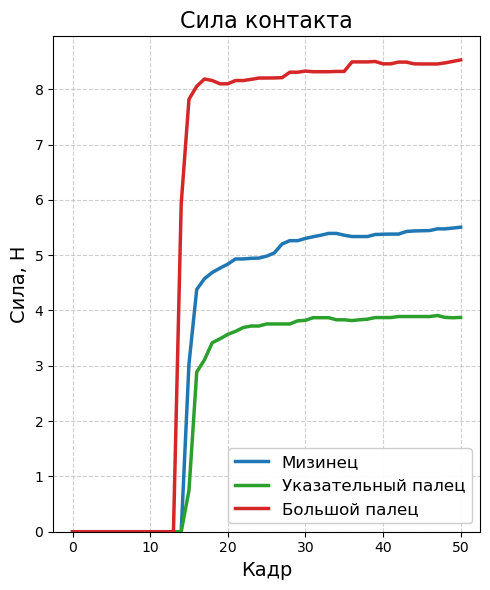

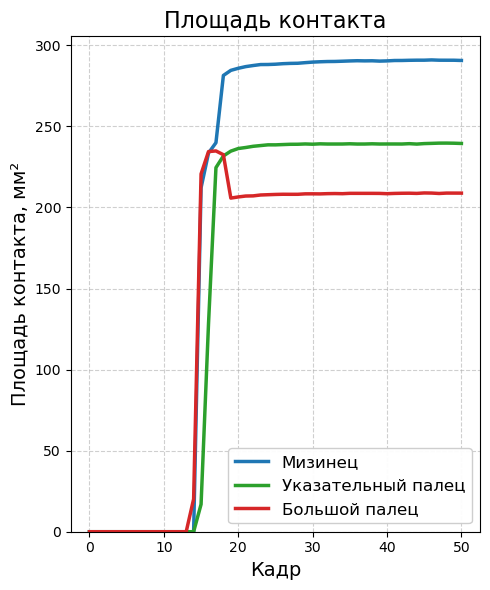

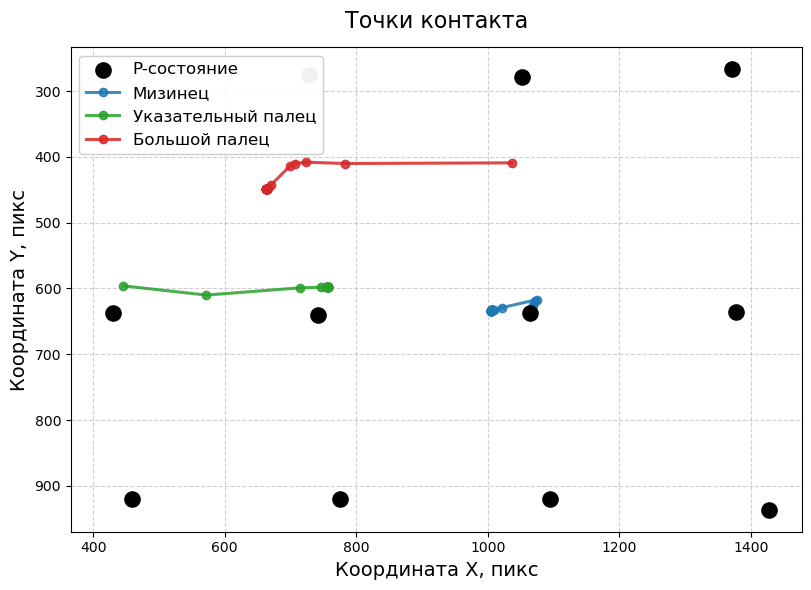


SVG файлы сохранены:
 • results\hand_cameras_inference\logdata_260203_121316\force_contact.svg
 • results\hand_cameras_inference\logdata_260203_121316\contact_area.svg
 • results\hand_cameras_inference\logdata_260203_121316\contact_centroids.svg


In [11]:
# -*- coding: utf-8 -*-
"""
Jupyter Notebook: Визуализация захваченных данных из .npz файла

Финальный вариант:
- Сила и площадь: линии без маркеров
- Центроиды: точки + траектории
- P-состояние: чёрные точки
- Названия каналов:
    2 → Большой палец
    1 → Указательный палец
    0 → Мизинец
- Легенды:
    * Графики 1–2: в столбик, справа снизу
    * График 3: в столбик, слева сверху, внутри графика
- Все графики сохраняются в SVG рядом с .npz
"""

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------- ПАРАМЕТРЫ -------------------------
npz_path = "results/hand_cameras_inference/logdata_260203_121316/captured_frames_A_20260203_121502.npz"
iqr_factor = 1.5
smoothing_window = 5
colors = ['tab:blue', 'tab:green', 'tab:red', 'tab:orange', 'tab:purple', 'tab:brown']
# -------------------------------------------------------------

# -------------------- ПУТИ СОХРАНЕНИЯ ------------------------
npz_path = Path(npz_path)
out_dir = npz_path.parent
svg_force_path     = out_dir / "force_contact.svg"
svg_area_path      = out_dir / "contact_area.svg"
svg_centroids_path = out_dir / "contact_centroids.svg"

# -------------------- ЗАГРУЗКА ДАННЫХ ------------------------
if not npz_path.exists():
    raise FileNotFoundError(f"Файл не найден: {npz_path}")

data = np.load(str(npz_path), allow_pickle=True)

def g(key):
    return data[key] if key in data else None

frame_indices      = g('frame_indices')
forces             = g('forces')
areas_mm2          = g('areas_mm2')
centroids_x        = g('centroids_x')
centroids_y        = g('centroids_y')
reference_P_sorted = g('reference_P_sorted')
meta_arr           = g('meta')

meta = meta_arr[0] if meta_arr is not None else {}
camera_ids = meta.get('camera_ids', [])

def safe_array(x):
    if x is None:
        return None
    arr = np.array(x, copy=False)
    if arr.dtype == object:
        try:
            return np.array([np.array(v, dtype=float) for v in arr])
        except Exception:
            return arr
    return arr

forces             = safe_array(forces)
areas_mm2          = safe_array(areas_mm2)
centroids_x        = safe_array(centroids_x)
centroids_y        = safe_array(centroids_y)
reference_P_sorted = safe_array(reference_P_sorted)

if frame_indices is None:
    frame_indices = np.arange(forces.shape[0])
else:
    frame_indices = np.array(frame_indices)

if not camera_ids:
    camera_ids = list(range(forces.shape[1]))

# -------------------- ИМЕНА ПАЛЬЦЕВ -------------------------
finger_names = {
    2: "Большой палец",
    1: "Указательный палец",
    0: "Мизинец"
}

def finger_label(idx):
    return finger_names.get(idx, f"Канал {idx}")

# -------------------- ФИЛЬТРАЦИЯ СИЛ -------------------------
def remove_outliers_iqr_1d(arr, factor=1.5):
    q1, q3 = np.nanpercentile(arr, [25, 75])
    iqr = q3 - q1
    low, high = q1 - factor * iqr, q3 + factor * iqr
    out = arr.astype(float)
    out[(out < low) | (out > high)] = np.nan
    return out

def median_smooth_1d(arr, window=5):
    out = np.empty_like(arr)
    for i in range(len(arr)):
        w = arr[max(0, i-window//2): i+window//2+1]
        out[i] = np.nanmedian(w)
    idx = np.arange(len(out))
    valid = np.isfinite(out)
    out = np.interp(idx, idx[valid], out[valid])
    return out

filtered_forces = np.column_stack([
    median_smooth_1d(
        remove_outliers_iqr_1d(forces[:, i], iqr_factor),
        smoothing_window
    )
    for i in range(forces.shape[1])
])

# ---------------------- ВИЗУАЛИЗАЦИЯ -------------------------
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# ГРАФИК 1: СИЛА
# ============================================================
fig1, ax1 = plt.subplots(figsize=(5, 6))

for i in range(filtered_forces.shape[1]):
    ax1.plot(frame_indices, filtered_forces[:, i],
             color=colors[i % len(colors)],
             linewidth=2.5,
             label=finger_label(i))

ax1.set_title('Сила контакта', fontsize=16)
ax1.set_xlabel('Кадр', fontsize=14)
ax1.set_ylabel('Сила, Н', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_ylim(bottom=0)
ax1.legend(fontsize=12, loc='lower right', framealpha=0.95, ncol=1)

plt.tight_layout()
fig1.savefig(svg_force_path, format='svg')
plt.show()

# ============================================================
# ГРАФИК 2: ПЛОЩАДЬ
# ============================================================
fig2, ax2 = plt.subplots(figsize=(5, 6))

for i in range(areas_mm2.shape[1]):
    ax2.plot(frame_indices, areas_mm2[:, i],
             color=colors[i % len(colors)],
             linewidth=2.5,
             label=finger_label(i))

ax2.set_title('Площадь контакта', fontsize=16)
ax2.set_xlabel('Кадр', fontsize=14)
ax2.set_ylabel('Площадь контакта, мм²', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_ylim(bottom=0)
ax2.legend(fontsize=12, loc='lower right', framealpha=0.95, ncol=1)

plt.tight_layout()
fig2.savefig(svg_area_path, format='svg')
plt.show()

# ---------------- ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ -------------------
def plot_contiguous_segments(ax, x, y, color, label=None):
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    idx = np.where(valid)[0]
    if idx.size == 0:
        return
    splits = np.where(np.diff(idx) != 1)[0] + 1
    groups = np.split(idx, splits)
    for j, g in enumerate(groups):
        ax.plot(
            x[g], y[g],
            '-o',
            color=color,
            linewidth=2.2,
            markersize=6,
            alpha=0.85,
            label=label if j == 0 else None
        )

# ============================================================
# ГРАФИК 3: ЦЕНТРОИДЫ И P-СОСТОЯНИЕ
# ============================================================
fig3, ax3 = plt.subplots(figsize=(10, 6))

if reference_P_sorted is not None and reference_P_sorted.size > 0:
    ax3.scatter(
        reference_P_sorted[:, 0],
        reference_P_sorted[:, 1],
        s=120,
        c='black',
        label='P-состояние',
        zorder=4
    )

for i in range(centroids_x.shape[1]):
    plot_contiguous_segments(
        ax3,
        centroids_x[:, i],
        centroids_y[:, i],
        colors[i % len(colors)],
        label=finger_label(i)
    )

ax3.set_title('Точки контакта', fontsize=16, pad=14)
ax3.set_xlabel('Координата X, пикс', fontsize=14)
ax3.set_ylabel('Координата Y, пикс', fontsize=14)
ax3.set_aspect('equal', adjustable='box')
ax3.invert_yaxis()
ax3.grid(True, linestyle='--', alpha=0.6)

ax3.legend(fontsize=12, loc='upper left', framealpha=0.95, ncol=1)

plt.tight_layout()
fig3.savefig(svg_centroids_path, format='svg')
plt.show()

print("\nSVG файлы сохранены:")
print(f" • {svg_force_path}")
print(f" • {svg_area_path}")
print(f" • {svg_centroids_path}")


# 5. Pareto front data

✓ Загружен CSV: comprehensive_metrics_v12_rewrite.csv


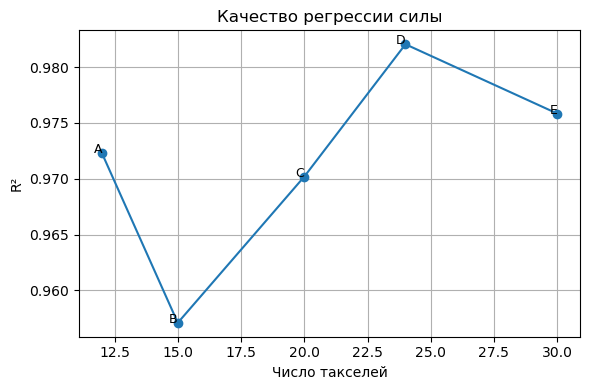

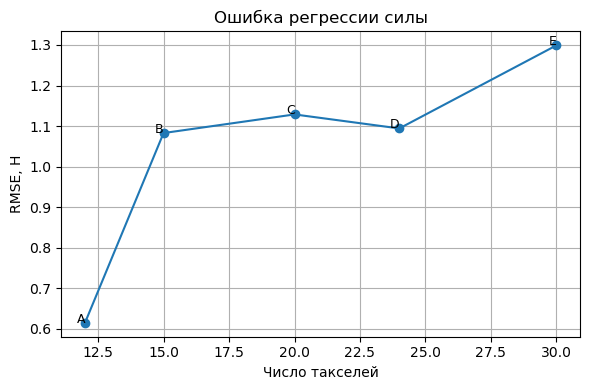


Использованные данные:


,sensor,taxels,diameter_mm,R2,RMSE_N,MAE_N,force_median_N,force_max_N,marker_loss_median_avg_pct10_50_px,pixel_noise_median_relerr,has_train_history
0,A,12,8.69,0.972295,0.615047,0.454587,3.350,19.15,82.565593,1.932922,True
1,B,15,6.94,0.957099,1.082903,0.809219,4.750,25.39,67.744401,2.857475,True
2,C,20,6.47,0.970191,1.128787,0.845226,5.455,31.98,64.200959,3.419956,True
3,D,24,5.75,0.982046,1.094237,0.813467,6.730,37.93,56.468196,3.771319,True
4,E,30,5.14,0.975839,1.299027,0.971860,7.020,35.96,51.080768,6.794346,True


In [3]:
# =========================
# ЗАГРУЗКА + ВИЗУАЛИЗАЦИЯ
# =========================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os

# -------------------------
# 1. ПУТИ
# -------------------------

BASE_DIR = Path(
    r"D:\Projects\Articles\Приборостроение 2025 сенсорика\Code\analysis_results_v12_rewrite"
)
TABLES_DIR = BASE_DIR / "tables"

csv_path  = TABLES_DIR / "comprehensive_metrics_v12_rewrite.csv"
xlsx_path = TABLES_DIR / "comprehensive_metrics_v12_rewrite.xlsx"

# -------------------------
# 2. ЗАГРУЗКА
# -------------------------

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"✓ Загружен CSV: {csv_path.name}")
elif xlsx_path.exists():
    df = pd.read_excel(xlsx_path)
    print(f"✓ Загружен XLSX: {xlsx_path.name}")
else:
    raise FileNotFoundError("CSV/XLSX не найден")

# -------------------------
# 3. ПРИВЕДЕНИЕ ТИПОВ
# -------------------------

num_cols = [
    'taxels',
    'diameter_mm',
    'R2',
    'RMSE_N',
    'MAE_N',
    'force_median_N',
    'force_max_N',
    'marker_loss_median_avg_pct10_50_px',
    'pixel_noise_median_relerr'
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# -------------------------
# 4. СОРТИРОВКА (ВАЖНО!)
# -------------------------

df = df.sort_values("taxels")

# -------------------------
# 5. НАСТРОЙКИ MATPLOTLIB
# -------------------------

plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.grid": True,
    "font.size": 10
})

# =========================
# 6. ГРАФИК 1 — R² vs TAXELS
# =========================

plt.figure()
plt.plot(df["taxels"], df["R2"], marker="o")
for _, r in df.iterrows():
    plt.text(r["taxels"], r["R2"], r["sensor"], fontsize=9, ha="right")

plt.xlabel("Число такселей")
plt.ylabel("R²")
plt.title("Качество регрессии силы")
plt.tight_layout()
plt.show()

# =========================
# 7. ГРАФИК 2 — RMSE vs TAXELS
# =========================

plt.figure()
plt.plot(df["taxels"], df["RMSE_N"], marker="o")
for _, r in df.iterrows():
    plt.text(r["taxels"], r["RMSE_N"], r["sensor"], fontsize=9, ha="right")

plt.xlabel("Число такселей")
plt.ylabel("RMSE, Н")
plt.title("Ошибка регрессии силы")
plt.tight_layout()
plt.show()

# =========================
# 8. КОНТРОЛЬ
# =========================

print("\nИспользованные данные:")
display(df)
